# Synthetic Signal Catalog: Monofractal & Multifractal

Analytical spectra and signal generators for WTMM validation.

- **Cell 1**: Monofractal analytical spectra (fBm, Weierstrass, Lévy)
- **Cell 2**: Monofractal signal examples
- **Cell 3**: Multifractal analytical spectra (Cantor, cascades, Feigenbaum)
- **Cell 4**: Multifractal signal examples
- **Cell 5**: CWT engine imports
- **Cell 6**: Signal selector — set `SIGNAL_NAME` to any label from the catalogs
- **Cells 7–10**: CWT, extrema/chains, partition functions, spectra (all use selected signal)

Loaded 3314561 samples from cwn1 (raw)
Time range: 1988.6104 to 2023.9739 (decimal year)
dt = 0.000004 year (2.0 min)
Value range: -32533.000 to 50000.000 counts
Start filter: 2008.207 -> 2008.5667 decimal year
After date filter: 2298046 samples
Using segment of 50000 samples starting at index 0
Segment time: 2008.5668 to 2009.5164
Segment value range: 746.000 to 2601.000 counts


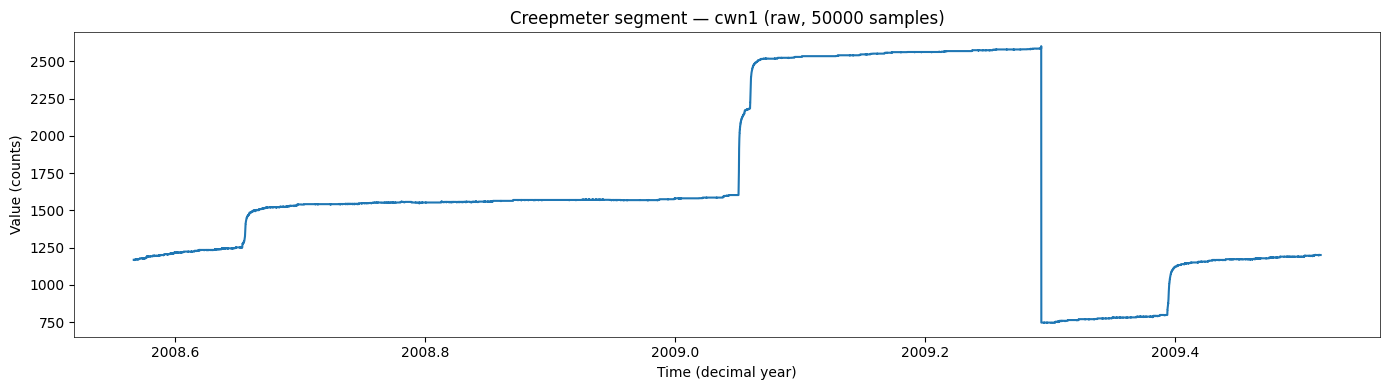

In [143]:
# CELL 22
# Load creepmeter data — configurable station and source
#
# No detrending — the creep signal IS the integral of the slip measure,
# analogous to prim(ucantor). WTMM analyzes the singularity structure
# in the trend itself. g2 has 2 vanishing moments so it already kills
# constant and linear components.
import numpy as np
import os
import gzip
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════
# CONFIGURE HERE
# ══════════════════════════════════════════════════════════════
# Option A: cleaned data (displacement in mm, gap-filled)
#   station = 'xmr1'
#   source = 'cleaned'
#
# Option B: raw data (counts, may need calibration)
#   station = 'cfwd'
#   source = 'raw'
#
station = 'cwn1'
source = 'raw'       # 'cleaned' or 'raw'
raw_era = 'new'      # 'new' or 'old' (only used when source='raw')
seg_len = 50000     # segment length (power of 2 recommended)
start_date = 2008.207    # e.g. 1997.200 = year 1997, day 200. None = auto
end_date = None      # e.g. 2005.365. None = auto
# ══════════════════════════════════════════════════════════════

base_dir = '/Users/amasaryk/projects/Creep'

if source == 'cleaned':
    # Try gz first, then plain
    candidates = [
        f'{base_dir}/Cleaned_data_creep/gz/{station}.10min.gz',
        f'{base_dir}/Cleaned_data_creep/{station}.10min.gz',
        f'{base_dir}/Cleaned_data_creep/{station}.10min',
    ]
    fpath = None
    for c in candidates:
        if os.path.exists(c):
            fpath = c
            break
    if fpath is None:
        raise FileNotFoundError(f'No cleaned file found for station {station}. '
                                f'Tried: {candidates}')
    opener = gzip.open if fpath.endswith('.gz') else open
    with opener(fpath, 'rt') as f:
        lines = f.readlines()
    unit = 'mm'
    bad_val = -9999

elif source == 'raw':
    # raw/new and raw/old
    candidates = [
        f'{base_dir}/Creepmeters_Raw/Creep/raw/{raw_era}/{station}',
    ]
    fpath = None
    for c in candidates:
        if os.path.exists(c):
            fpath = c
            break
    if fpath is None:
        # List available raw files to help the user
        raw_dir = f'{base_dir}/Creepmeters_Raw/Creep/raw/{raw_era}/'
        if os.path.isdir(raw_dir):
            avail = sorted(os.listdir(raw_dir))
            print(f'Available raw files: {avail}')
        raise FileNotFoundError(f'No raw file found for station {station}. '
                                f'Tried: {candidates}')
    with open(fpath, 'r') as f:
        lines = f.readlines()
    unit = 'counts'
    bad_val = -9999
else:
    raise ValueError(f"source must be 'cleaned' or 'raw', got '{source}'")

# Parse: year  day_of_year  value
data = []
for line in lines:
    parts = line.strip().split()
    if len(parts) >= 3:
        try:
            year = float(parts[0])
            doy = float(parts[1])
            val = float(parts[2])
            if val != bad_val:
                t_val = year + doy / 365.25
                data.append((t_val, val))
        except ValueError:
            continue

data = np.array(data)
t_creep = data[:, 0]
x_creep = data[:, 1]
dt_creep = np.median(np.diff(t_creep))

print(f'Loaded {len(x_creep)} samples from {os.path.basename(fpath)} ({source})')
print(f'Time range: {t_creep[0]:.4f} to {t_creep[-1]:.4f} (decimal year)')
print(f'dt = {dt_creep:.6f} year ({dt_creep * 365.25 * 24 * 60:.1f} min)')
print(f'Value range: {x_creep.min():.3f} to {x_creep.max():.3f} {unit}')

# Apply date range filter if specified
if start_date is not None or end_date is not None:
    # Convert year.doy to decimal year
    def doy_to_decimal(ydoy):
        yr = int(ydoy)
        doy = (ydoy - yr) * 1000  # e.g. 1997.200 -> year=1997, doy=200
        return yr + doy / 365.25
    
    mask = np.ones(len(t_creep), dtype=bool)
    if start_date is not None:
        t_start = doy_to_decimal(start_date)
        mask &= t_creep >= t_start
        print(f'Start filter: {start_date} -> {t_start:.4f} decimal year')
    if end_date is not None:
        t_end = doy_to_decimal(end_date)
        mask &= t_creep <= t_end
        print(f'End filter: {end_date} -> {t_end:.4f} decimal year')
    
    t_creep = t_creep[mask]
    x_creep = x_creep[mask]
    print(f'After date filter: {len(x_creep)} samples')

# Find a clean segment (no gaps)
seg_len = min(seg_len, len(x_creep))
found_clean = False
for start in range(0, len(x_creep) - seg_len, seg_len // 4):
    segment_c = x_creep[start:start + seg_len]
    t_seg_c = t_creep[start:start + seg_len]
    gaps = np.diff(t_seg_c)
    if np.all(np.abs(gaps - dt_creep) < dt_creep * 0.5):
        found_clean = True
        break

if not found_clean:
    # Fall back to first seg_len contiguous samples
    start = 0
    segment_c = x_creep[:seg_len]
    t_seg_c = t_creep[:seg_len]
    print(f'WARNING: no perfectly clean segment found, using first {seg_len} samples')

segment_c = segment_c.copy()
print(f'Using segment of {len(segment_c)} samples starting at index {start}')
print(f'Segment time: {t_seg_c[0]:.4f} to {t_seg_c[-1]:.4f}')
print(f'Segment value range: {segment_c.min():.3f} to {segment_c.max():.3f} {unit}')

fig, ax = plt.subplots(figsize=(14, 4))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
ax.plot(t_seg_c, segment_c)
ax.set_xlabel('Time (decimal year)')
ax.set_ylabel(f'Value ({unit})')
ax.set_title(f'Creepmeter segment — {station} ({source}, {len(segment_c)} samples)')
plt.tight_layout()
plt.show()

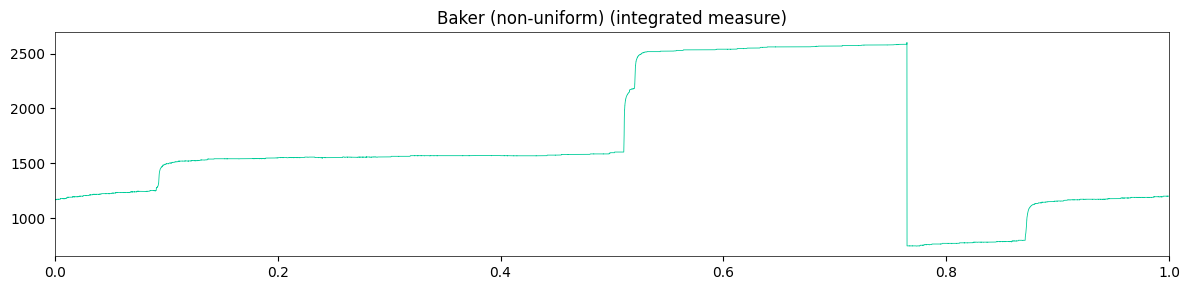

Signal size: 50000
Signal range: [746.0000, 2601.0000]
CWT computed in 1.596s  (n_oct=5, n_voice=12, 60 scales)
Coefficients shape: (60, 50000), Scales: 60 (1.00 to 30.20)
Valid range at finest scale: (20, 49979), coarsest: (618, 49381)


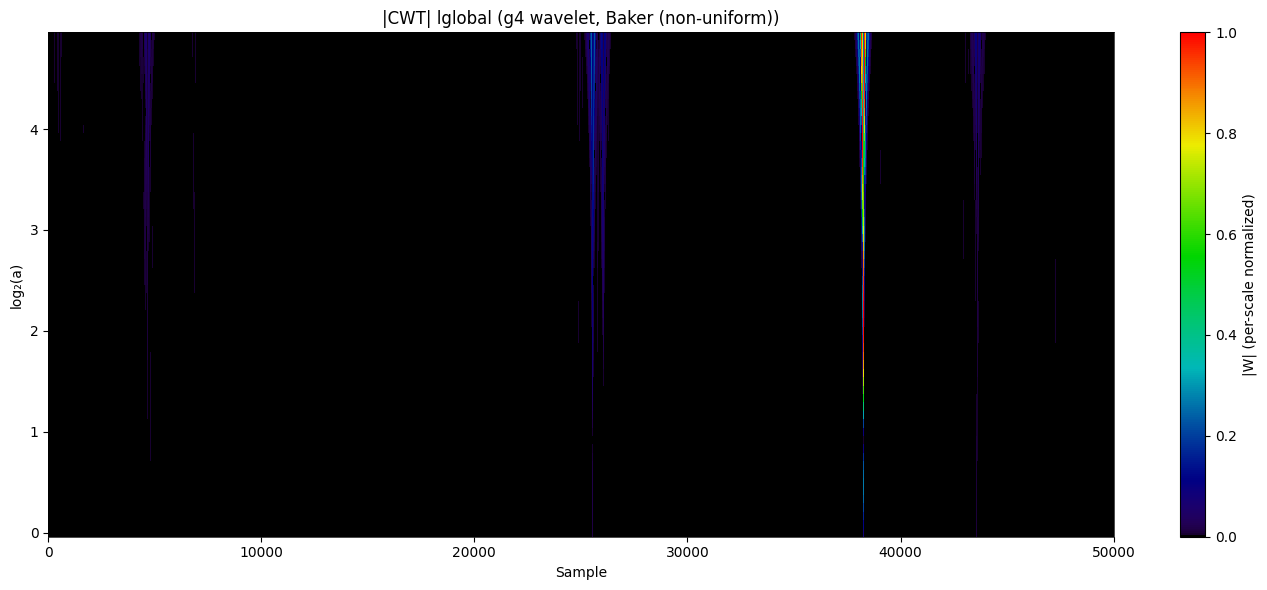

In [ ]:
# Cell 13: CWT on selected signal
#SIG_START = 0          # start index                                                                                                                               
#SIG_END = SIZE // 2    # end index (e.g., first half)                                                                                                            
                                                                                                                                                                    
#analysis_signal = analysis_signal[SIG_START:SIG_END]                                                                                                               
#SIZE = len(segment_c)




analysis_signal = segment_c
SIZE = len(analysis_signal)

# --- CWT parameters (used by all downstream cells) ---
N_OCT = 5
N_VOICE = 12
A_MIN = 1.0
EXPO = -1.0

fig, ax = plt.subplots(figsize=(12, 3))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
t_axis = np.arange(SIZE) / SIZE
ax.plot(t_axis, analysis_signal, color=analysis_color, linewidth=0.6)
ax.set_title(f'{analysis_label}{" (integrated measure)" if is_measure else ""}')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f'Signal size: {SIZE}')
print(f'Signal range: [{analysis_signal.min():.4f}, {analysis_signal.max():.4f}]')

# CWT + visualization
t0 = time.time()
coeffs, scales, valid_ranges = cwtd_fftw(segment_c, a_min=A_MIN, n_oct=N_OCT, n_voice=N_VOICE,
                                     wavelet_name='g4', expo=EXPO)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s  (n_oct={N_OCT}, n_voice={N_VOICE}, {len(scales)} scales)')
print(f'Coefficients shape: {coeffs.shape}, Scales: {len(scales)} ({scales[0]:.2f} to {scales[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges[0]}, coarsest: {valid_ranges[-1]}')

# Plot scalogram
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
im = scalogram_lastwave(coeffs, scales=scales, ax=ax,
                        norm_mode='lglobal')
ax.set_title(f'|CWT| lglobal (g4 wavelet, {analysis_label})')
plt.colorbar(im, ax=ax, label='|W| (per-scale normalized)')
plt.tight_layout()
plt.show()


Numba warmup: 0.001s
Total extrema: 84580
Extrema computed in 0.019s
  Scale 0 (a=1.00): 3087 extrema
  Scale 15 (a=2.38): 2060 extrema
  Scale 30 (a=5.66): 1241 extrema
  Scale 45 (a=13.45): 625 extrema
  Scale 59 (a=30.20): 291 extrema
Chaining: 0.002s
Delete: 0.086s, deleted 18 chains
Pre-chainmax surviving chains: 3013
ChainMax: 0.059s
Total chaining: 0.148s
Remaining extrema: 84562
Pre-deletion chains: 3014
Surviving chains: 3013
Deleted chains: 1


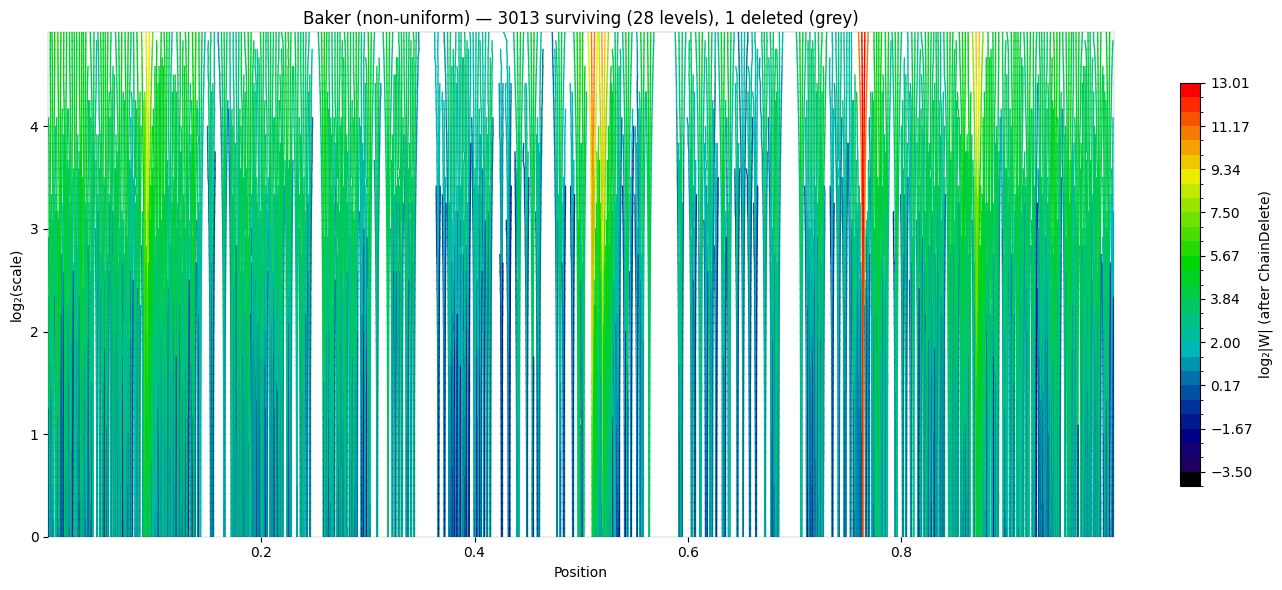

In [ ]:
# Cell 15: Extrema detection — now imported from wtmm package
from wtmm.extrema import compute_extlis_numba, compute_extrep

# Compute extrema representation
dx_signal = 1.0 / SIZE
t0 = time.time()
# Warm up Numba
_ = compute_extlis_numba(coeffs[0], dx_signal, 0.0, 1e-6,
                          valid_ranges[0][0], valid_ranges[0][1])
t_warmup = time.time()
print(f'Numba warmup: {t_warmup - t0:.3f}s')

extrep_abs, extrep_ord, extrep_idx = compute_extrep(
    coeffs, scales, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN,
    valid_ranges=valid_ranges, dx=dx_signal, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t_warmup:.3f}s')
n_total_scales = N_OCT * N_VOICE
for sidx in [0, n_total_scales//4, n_total_scales//2, 3*n_total_scales//4, n_total_scales-1]:
    print(f'  Scale {sidx} (a={scales[sidx]:.2f}): {len(extrep_abs[sidx])} extrema')

# Cell 16: Chaining — now imported from wtmm package
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper, trace_chains, save_chain_state

# Run full chaining pipeline
t0 = time.time()
coarser_links, finer_links = chain_all(extrep_abs, extrep_ord, n_oct=N_OCT, n_voice=N_VOICE)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs, pre_del_ord, pre_del_cl = save_chain_state(extrep_abs, extrep_ord, coarser_links)
pre_del_chains = trace_chains(pre_del_abs, pre_del_ord, pre_del_cl, scales, N_OCT * N_VOICE)

nb_del = chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                           coarser_links, finer_links, n_oct=N_OCT, n_voice=N_VOICE)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

# Trace chains BEFORE chainmax (raw CWT modulus values)
pre_chainmax_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, N_OCT * N_VOICE)
print(f'Pre-chainmax surviving chains: {len(pre_chainmax_chains)}')

# ChainMax with expo=1
chain_max_wrapper(extrep_ord, coarser_links, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN, expo=0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')
print(f'Total chaining: {t1 - t0:.3f}s')

remaining = sum(len(a) for a in extrep_abs)
print(f'Remaining extrema: {remaining}')

# Cell 17: Extrema representation and maxima lines visualization

# Surviving chains (after deletion)
post_del_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, N_OCT * N_VOICE)

# Find which pre-deletion chains were deleted (not present in post-deletion)
# Build set of surviving chain start positions for fast lookup
surviving_starts = set()
for pos, sv, sign, vals in post_del_chains:
    surviving_starts.add((pos[0], sign))

deleted_chains = []
for pos, sv, sign, vals in pre_del_chains:
    if (pos[0], sign) not in surviving_starts:
        deleted_chains.append((pos, sv, sign, vals))

print(f'Pre-deletion chains: {len(pre_del_chains)}')
print(f'Surviving chains: {len(post_del_chains)}')
print(f'Deleted chains: {len(deleted_chains)}')

# Plot maxima lines: surviving colored by log2|ordinate|, deleted greyed out
import matplotlib as mpl

N_COLORS = 28
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.1)

# Draw deleted chains first (background, grey)
for pos, sv, sign, vals in deleted_chains:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

# Collect all log2|ordinate| values for colormap normalization
all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300) for _, _, _, vals in post_del_chains])
vmin, vmax = np.percentile(all_log2_vals, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

# Draw surviving chains colored by log2|ordinate| at each segment
for pos, sv, sign, vals in post_del_chains:
    log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
    for j in range(len(pos) - 1):
        ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log\u2082|W| (after ChainDelete)', shrink=0.8)

ax.set_xlabel('Position')
ax.set_ylabel('log\u2082(scale)')
ax.set_title(f'{analysis_label} \u2014 {len(post_del_chains)} surviving ({N_COLORS} levels), {len(deleted_chains)} deleted (grey)')
ax.margins(0)
plt.tight_layout()
plt.show()


Chains passing filter: 555 / 3013 (threshold: log2(a) min 4)


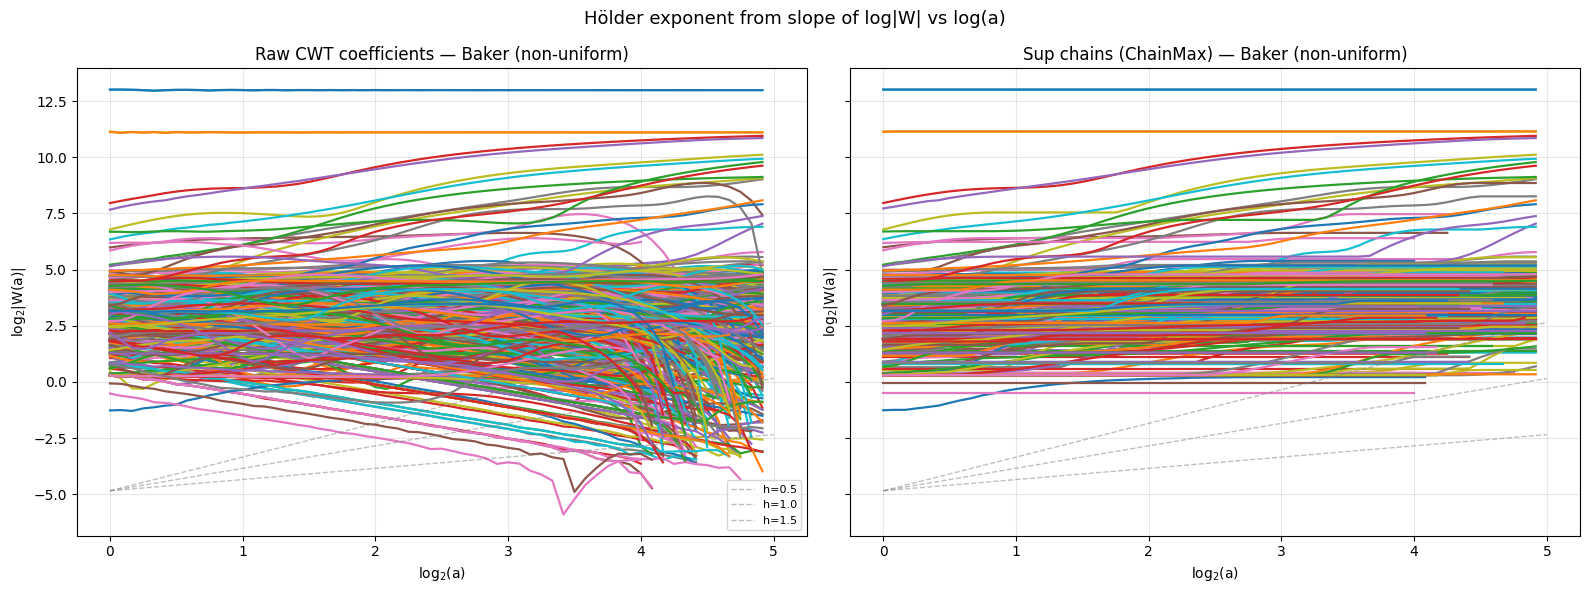

In [ ]:
# Hölder exponent visualization: log|W(a)| vs log2(a) for each chain
# Left: raw CWT coefficients along chains
# Right: sup (chainmax) values along chains
# Slope = Hölder exponent h (+ 1/2 for L2 normalization)

SCALE_THRESH = 4       # log2(a) threshold value
SCALE_THRESH_MODE = 'min' # 'min' = chain must reach at least this scale; 'max' = chain must not exceed
MAX_CHAINS_PLOT = 3000    # cap to avoid overplotting

# Re-trace chains collecting raw coeffs + chainmax ordinates + scale indices
n_scales_total = N_OCT * N_VOICE
raw_chains = []
sup_chains = []

for fi in range(len(extrep_abs[0])):
    log2_s = []
    raw_vals = []
    sup_vals = []
    cs, ci = 0, fi
    while cs < n_scales_total and ci != -1:
        log2_s.append(np.log2(scales[cs]))
        eidx = extrep_idx[cs][ci]
        raw_vals.append(coeffs[cs, eidx])
        sup_vals.append(extrep_ord[cs][ci])
        ci = coarser_links[cs][ci]
        cs += 1
    if len(log2_s) > 1:
        log2_s = np.array(log2_s)
        raw_log2 = np.log2(np.abs(np.array(raw_vals)) + 1e-300)
        sup_log2 = np.log2(np.abs(np.array(sup_vals)) + 1e-300)
        raw_chains.append((log2_s, raw_log2))
        sup_chains.append((log2_s, sup_log2))

# Filter by scale threshold
filtered_idx = []
for i, (log2_s, _) in enumerate(raw_chains):
    max_scale = log2_s.max()
    min_scale = log2_s.min()
    if SCALE_THRESH_MODE == 'min':
        if max_scale >= SCALE_THRESH:
            filtered_idx.append(i)
    else:  # 'max'
        if max_scale <= SCALE_THRESH:
            filtered_idx.append(i)

# Subsample if too many
if len(filtered_idx) > MAX_CHAINS_PLOT:
    rng = np.random.default_rng(42)
    filtered_idx = sorted(rng.choice(filtered_idx, MAX_CHAINS_PLOT, replace=False))

print(f'Chains passing filter: {len(filtered_idx)} / {len(raw_chains)} '
      f'(threshold: log2(a) {SCALE_THRESH_MODE} {SCALE_THRESH})')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for panel, (ax, chains, title) in enumerate(zip(
        axes,
        [raw_chains, sup_chains],
        ['Raw CWT coefficients', 'Sup chains (ChainMax)'])):
    for i in filtered_idx:
        log2_s, log2_v = chains[i]
        ax.plot(log2_s, log2_v, '-', alpha=1, linewidth=1.6)
    ax.set_xlabel('log$_2$(a)')
    ax.set_ylabel('log$_2$|W(a)|')
    ax.set_title(f'{title} — {analysis_label}')
    ax.grid(True, alpha=0.3)
    # Reference slopes
    for h in [0.5, 1.0, 1.5]:
        x_ref = np.array([0, N_OCT])
        ax.plot(x_ref, h * x_ref + ax.get_ylim()[0] + 2, '--', color='grey',
                alpha=0.5, linewidth=1, label=f'h={h}' if panel == 0 else None)

axes[0].legend(fontsize=8, loc='lower right')
plt.suptitle(f'Hölder exponent from slope of log|W| vs log(a)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Chain removal by raw CWT coefficient magnitude
# Sensor resets produce Hölder ~0 extrema with anomalously large
# |W| at fine scales. Remove chains whose raw log₂|W| exceeds a
# threshold at a given voice range.
#
# After removal, re-runs ChainMax on the cleaned skeleton.

REMOVE_BY_COEFF = True

# --- Configure ---
VOICE_MIN = 0          # finest voice index to check (0 = finest scale)
VOICE_MAX = 12         # coarsest voice index to check
LOG2_COEFF_THRESH = 10 # remove chains with log₂|raw W| > this at ANY voice in range
# ------------------

if REMOVE_BY_COEFF:
    n_scales_total = N_OCT * N_VOICE
    n_finest = len(extrep_abs[0])

    # Walk each chain from finest scale, check raw coeffs in voice range
    remove_mask = np.zeros(n_finest, dtype=bool)
    for fi in range(n_finest):
        cs, ci = 0, fi
        while cs < n_scales_total and ci != -1:
            if VOICE_MIN <= cs <= VOICE_MAX:
                eidx = extrep_idx[cs][ci]
                raw_log2 = np.log2(np.abs(coeffs[cs, eidx]) + 1e-300)
                if raw_log2 > LOG2_COEFF_THRESH:
                    remove_mask[fi] = True
                    break
            ci = coarser_links[cs][ci]
            cs += 1

    # Collect all extrema to remove (walk flagged chains fully)
    remove_set = [set() for _ in range(len(extrep_abs))]
    for fi in range(n_finest):
        if not remove_mask[fi]:
            continue
        cs, ci = 0, fi
        while cs < len(extrep_abs) and ci != -1:
            remove_set[cs].add(ci)
            ci = coarser_links[cs][ci]
            cs += 1

    # Rebuild extrep arrays with index remapping (same pattern as COI filter)
    n_removed_total = 0
    old_to_new = []
    for s in range(len(extrep_abs)):
        n_old = len(extrep_abs[s])
        to_remove = remove_set[s]
        n_removed_total += len(to_remove)

        if len(to_remove) == 0:
            old_to_new.append({i: i for i in range(n_old)})
            continue

        keep_mask = np.array([i not in to_remove for i in range(n_old)])
        mapping = {}
        new_idx = 0
        for old_idx in range(n_old):
            if keep_mask[old_idx]:
                mapping[old_idx] = new_idx
                new_idx += 1
            else:
                mapping[old_idx] = -1
        old_to_new.append(mapping)

        extrep_abs[s] = extrep_abs[s][keep_mask]
        extrep_ord[s] = extrep_ord[s][keep_mask]
        extrep_idx[s] = extrep_idx[s][keep_mask]

    # Fix up coarser_links and finer_links
    for s in range(len(coarser_links)):
        n_cur = len(extrep_abs[s])
        new_cl = np.full(n_cur, -1, dtype=int)
        new_fl = np.full(n_cur, -1, dtype=int)

        old_cl = coarser_links[s]
        old_fl = finer_links[s]
        mapping_cur = old_to_new[s]
        mapping_coarser = old_to_new[s + 1] if s + 1 < len(old_to_new) else {}
        mapping_finer = old_to_new[s - 1] if s > 0 else {}

        for old_idx, new_idx in mapping_cur.items():
            if new_idx == -1:
                continue
            if old_idx < len(old_cl):
                old_target = old_cl[old_idx]
                if old_target != -1 and old_target in mapping_coarser:
                    new_cl[new_idx] = mapping_coarser[old_target]
                else:
                    new_cl[new_idx] = -1
            if old_idx < len(old_fl):
                old_target = old_fl[old_idx]
                if old_target != -1 and old_target in mapping_finer:
                    new_fl[new_idx] = mapping_finer[old_target]
                else:
                    new_fl[new_idx] = -1

        coarser_links[s] = new_cl
        finer_links[s] = new_fl

    n_flagged = int(remove_mask.sum())
    n_remaining = sum(len(a) for a in extrep_abs)
    print(f'Coefficient filter: removed {n_flagged} chains ({n_removed_total} extrema)')
    print(f'  Criterion: log₂|raw W| > {LOG2_COEFF_THRESH} at voices [{VOICE_MIN}, {VOICE_MAX}]')
    print(f'  Remaining extrema: {n_remaining}')

    # Re-run ChainMax on cleaned skeleton
    chain_max_wrapper(extrep_ord, coarser_links, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN, expo=0)

    # Re-trace and visualize
    post_filter_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, n_scales_total)
    print(f'  Surviving chains after filter + chainmax: {len(post_filter_chains)}')

    # Plot maxima lines after filtering
    import matplotlib as mpl
    N_COLORS = 28
    fig, ax = plt.subplots(figsize=(14, 6))
    for spine in ax.spines.values(): spine.set_linewidth(0.1)

    all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300)
                                    for _, _, _, vals in post_filter_chains])
    vmin, vmax = np.percentile(all_log2_vals, [0, 100])
    boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
    norm = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
    cmap = lastwave_colormap(N_COLORS)

    for pos, sv, sign, vals in post_filter_chains:
        log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
        for j in range(len(pos) - 1):
            ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=ax, label='log₂|W| (after coeff filter)', shrink=0.8)
    ax.set_xlabel('Position')
    ax.set_ylabel('log₂(scale)')
    ax.set_title(f'{len(post_filter_chains)} chains after removing {n_flagged} '
                 f'(log₂|W| > {LOG2_COEFF_THRESH} at voices [{VOICE_MIN},{VOICE_MAX}])')
    ax.margins(0)
    plt.tight_layout()
    plt.show()
else:
    print('Coefficient filtering: disabled (REMOVE_BY_COEFF = False)')

In [ ]:
# Remove chains whose post-chainmax sup is at the finest scale
# After chainmax, if the largest |W| is still at voice 0, the chain
# never truly grew with scale — it's h ≤ 0. Physical singularities
# in displacement (h > 0) will have their sup at a coarser scale.

REMOVE_FLAT_CHAINS = True

if REMOVE_FLAT_CHAINS:
    n_scales_total = N_OCT * N_VOICE
    n_finest = len(extrep_abs[0])

    remove_mask = np.zeros(n_finest, dtype=bool)
    for fi in range(n_finest):
        # Walk chain, find scale of post-chainmax sup
        max_cm = -1.0
        max_cs = 0
        cs, ci = 0, fi
        chain_len = 0
        while cs < n_scales_total and ci != -1:
            val = abs(extrep_ord[cs][ci])
            if val > max_cm:
                max_cm = val
                max_cs = cs
            chain_len += 1
            ci = coarser_links[cs][ci]
            cs += 1

        if chain_len < 2 or max_cs == 0:
            remove_mask[fi] = True

    # Collect all extrema to remove
    remove_set = [set() for _ in range(len(extrep_abs))]
    for fi in range(n_finest):
        if not remove_mask[fi]:
            continue
        cs, ci = 0, fi
        while cs < len(extrep_abs) and ci != -1:
            remove_set[cs].add(ci)
            ci = coarser_links[cs][ci]
            cs += 1

    # Rebuild arrays
    n_removed_total = 0
    old_to_new = []
    for s in range(len(extrep_abs)):
        n_old = len(extrep_abs[s])
        to_remove = remove_set[s]
        n_removed_total += len(to_remove)

        if len(to_remove) == 0:
            old_to_new.append({i: i for i in range(n_old)})
            continue

        keep_mask = np.array([i not in to_remove for i in range(n_old)])
        mapping = {}
        new_idx = 0
        for old_idx in range(n_old):
            if keep_mask[old_idx]:
                mapping[old_idx] = new_idx
                new_idx += 1
            else:
                mapping[old_idx] = -1
        old_to_new.append(mapping)

        extrep_abs[s] = extrep_abs[s][keep_mask]
        extrep_ord[s] = extrep_ord[s][keep_mask]
        extrep_idx[s] = extrep_idx[s][keep_mask]

    for s in range(len(coarser_links)):
        n_cur = len(extrep_abs[s])
        new_cl = np.full(n_cur, -1, dtype=int)
        new_fl = np.full(n_cur, -1, dtype=int)

        old_cl = coarser_links[s]
        old_fl = finer_links[s]
        mapping_cur = old_to_new[s]
        mapping_coarser = old_to_new[s + 1] if s + 1 < len(old_to_new) else {}
        mapping_finer = old_to_new[s - 1] if s > 0 else {}

        for old_idx, new_idx in mapping_cur.items():
            if new_idx == -1:
                continue
            if old_idx < len(old_cl):
                old_target = old_cl[old_idx]
                if old_target != -1 and old_target in mapping_coarser:
                    new_cl[new_idx] = mapping_coarser[old_target]
                else:
                    new_cl[new_idx] = -1
            if old_idx < len(old_fl):
                old_target = old_fl[old_idx]
                if old_target != -1 and old_target in mapping_finer:
                    new_fl[new_idx] = mapping_finer[old_target]
                else:
                    new_fl[new_idx] = -1

        coarser_links[s] = new_cl
        finer_links[s] = new_fl

    n_flagged = int(remove_mask.sum())
    n_remaining = sum(len(a) for a in extrep_abs)
    print(f'Sup-at-finest filter: removed {n_flagged} chains ({n_removed_total} extrema)')
    print(f'  Remaining extrema: {n_remaining}')

    # Visualize
    post_flat_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, n_scales_total)
    print(f'  Surviving chains: {len(post_flat_chains)}')

    import matplotlib as mpl
    N_COLORS = 28
    fig, ax = plt.subplots(figsize=(14, 6))
    for spine in ax.spines.values(): spine.set_linewidth(0.1)

    all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300)
                                    for _, _, _, vals in post_flat_chains])
    vmin, vmax = np.percentile(all_log2_vals, [0, 100])
    boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
    norm = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
    cmap = lastwave_colormap(N_COLORS)

    for pos, sv, sign, vals in post_flat_chains:
        log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
        for j in range(len(pos) - 1):
            ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=ax, label='log₂|W| (after flat removal)', shrink=0.8)
    ax.set_xlabel('Position')
    ax.set_ylabel('log₂(scale)')
    ax.set_title(f'{len(post_flat_chains)} chains after removing {n_flagged} with post-chainmax sup at voice 0')
    ax.margins(0)
    plt.tight_layout()
    plt.show()
else:
    print('Flat-chain filtering: disabled (REMOVE_FLAT_CHAINS = False)')

In [ ]:
# Split chains by post-chainmax sup location
# Uses pre_chainmax_chains (saved before flat-chain removal in cell 10)
# Left: chains whose sup is NOT at voice 0 — plot post-chainmax values
# Right: chains whose sup IS at voice 0 — plot raw (pre-chainmax) values

import matplotlib.pyplot as plt
import numpy as np

n_scales_total = N_OCT * N_VOICE

sup_coarse = []  # (log2_a, log2w) — sup at coarser scale
sup_finest = []  # sup at voice 0

for fi in range(len(extrep_abs[0])):
    # Walk surviving chains (post cell 10) for the "good" group
    log2_a_list = []
    cm_list = []
    max_cm = -1.0
    max_cs = 0
    cs, ci = 0, fi
    while cs < n_scales_total and ci != -1:
        log2_a_list.append(np.log2(scales[cs]))
        val = abs(extrep_ord[cs][ci])
        cm_list.append(np.log2(val + 1e-300))
        if val > max_cm:
            max_cm = val
            max_cs = cs
        ci = coarser_links[cs][ci]
        cs += 1
    if len(log2_a_list) >= 2:
        sup_coarse.append((np.array(log2_a_list), np.array(cm_list)))

# For the removed chains, use pre_chainmax_chains (saved in cell 7, before any removal)
# These have raw CWT values; check sup location on those
for pos, sv, sign, vals in pre_chainmax_chains:
    if len(sv) < 2:
        continue
    abs_vals = np.abs(np.array(vals))
    max_idx = np.argmax(abs_vals)
    if max_idx == 0:  # sup at finest scale
        log2_a = np.array(sv)
        log2_w = np.log2(abs_vals + 1e-300)
        sup_finest.append((log2_a, log2_w))

print(f'Sup at coarser scale (surviving): {len(sup_coarse)} chains')
print(f'Sup at voice 0 (removed, from pre-chainmax): {len(sup_finest)} chains')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Left: sup NOT at voice 0 — post-chainmax
ax = axes[0]
for log2_a, log2_w in sup_coarse:
    ax.plot(log2_a, log2_w, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'Sup at coarser scale (post-chainmax)\n{len(sup_coarse)} chains')
ax.grid(True, alpha=0.2)

# Right: sup at voice 0 — raw pre-chainmax
ax = axes[1]
for log2_a, log2_w in sup_finest:
    ax.plot(log2_a, log2_w, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'Sup at voice 0 (raw, pre-chainmax)\n{len(sup_finest)} chains')
ax.grid(True, alpha=0.2)

plt.suptitle('Chains split by post-chainmax sup location', fontsize=13)
plt.tight_layout()
plt.show()

Sup coarser (h>0 group): 1421 chains, h median=0.144, R² median=0.705
Sup finest  (h≤0 group): 1513 chains, h median=-1.181, R² median=0.903


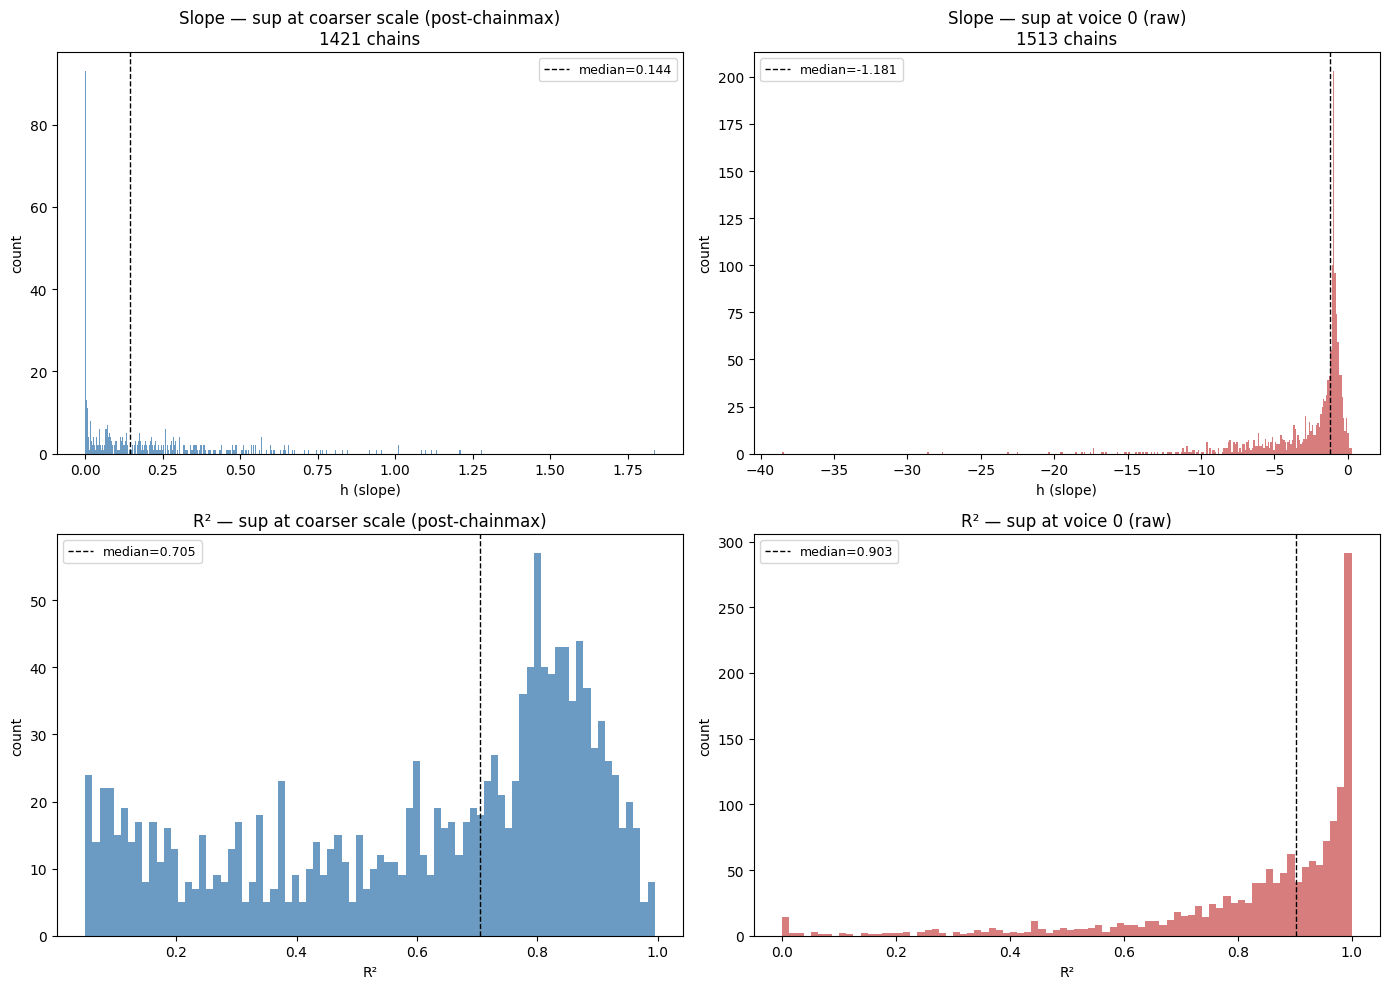

In [204]:
# Histograms of Hölder exponent (slope) and R² for both chain groups
import matplotlib.pyplot as plt
import numpy as np

# Compute slopes and R² for sup-at-coarser chains (post-chainmax)
h_pos = []
r2_pos = []
for log2_a, log2_w in sup_coarse:
    if len(log2_a) < 3:
        continue
    coeffs_fit = np.polyfit(log2_a, log2_w, 1)
    slope = coeffs_fit[0]
    pred = np.polyval(coeffs_fit, log2_a)
    ss_res = np.sum((log2_w - pred)**2)
    ss_tot = np.sum((log2_w - np.mean(log2_w))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
    h_pos.append(slope)
    r2_pos.append(r2)

# Compute slopes and R² for sup-at-finest chains (raw, pre-chainmax)
h_neg = []
r2_neg = []
for log2_a, log2_w in sup_finest:
    if len(log2_a) < 3:
        continue
    coeffs_fit = np.polyfit(log2_a, log2_w, 1)
    slope = coeffs_fit[0]
    pred = np.polyval(coeffs_fit, log2_a)
    ss_res = np.sum((log2_w - pred)**2)
    ss_tot = np.sum((log2_w - np.mean(log2_w))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
    h_neg.append(slope)
    r2_neg.append(r2)

h_pos = np.array(h_pos)
r2_pos = np.array(r2_pos)
h_neg = np.array(h_neg)
r2_neg = np.array(r2_neg)

print(f'Sup coarser (h>0 group): {len(h_pos)} chains, h median={np.median(h_pos):.3f}, R² median={np.median(r2_pos):.3f}')
print(f'Sup finest  (h≤0 group): {len(h_neg)} chains, h median={np.median(h_neg):.3f}, R² median={np.median(r2_neg):.3f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: slope histogram — h>0 group (post-chainmax)
ax = axes[0, 0]
ax.hist(h_pos, bins=2000, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(np.median(h_pos), color='k', ls='--', lw=1, label=f'median={np.median(h_pos):.3f}')
ax.set_xlabel('h (slope)')
ax.set_ylabel('count')
ax.set_title(f'Slope — sup at coarser scale (post-chainmax)\n{len(h_pos)} chains')
ax.legend(fontsize=9)

# Top right: slope histogram — h≤0 group (raw)
ax = axes[0, 1]
ax.hist(h_neg, bins=400, color='indianred', alpha=0.8, edgecolor='none')
ax.axvline(np.median(h_neg), color='k', ls='--', lw=1, label=f'median={np.median(h_neg):.3f}')
ax.set_xlabel('h (slope)')
ax.set_ylabel('count')
ax.set_title(f'Slope — sup at voice 0 (raw)\n{len(h_neg)} chains')
ax.legend(fontsize=9)

# Bottom left: R² histogram — h>0 group
ax = axes[1, 0]
ax.hist(r2_pos, bins=80, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(np.median(r2_pos), color='k', ls='--', lw=1, label=f'median={np.median(r2_pos):.3f}')
ax.set_xlabel('R²')
ax.set_ylabel('count')
ax.set_title(f'R² — sup at coarser scale (post-chainmax)')
ax.legend(fontsize=9)

# Bottom right: R² histogram — h≤0 group
ax = axes[1, 1]
ax.hist(r2_neg, bins=80, color='indianred', alpha=0.8, edgecolor='none')
ax.axvline(np.median(r2_neg), color='k', ls='--', lw=1, label=f'median={np.median(r2_neg):.3f}')
ax.set_xlabel('R²')
ax.set_ylabel('count')
ax.set_title(f'R² — sup at voice 0 (raw)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Finite difference derivatives d(log₂|W|)/d(log₂a) for both groups
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Left: sup at coarser scale (post-chainmax)
ax = axes[0]
for log2_a, log2_w in sup_coarse:
    if len(log2_a) < 2:
        continue
    d_log2w = np.diff(log2_w)
    d_log2a = np.diff(log2_a)
    deriv = d_log2w / d_log2a
    mid_a = 0.5 * (log2_a[:-1] + log2_a[1:])
    ax.plot(mid_a, deriv, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('d(log₂|W|) / d(log₂a)')
ax.set_title(f'Sup at coarser scale (post-chainmax)\n{len(sup_coarse)} chains')
ax.grid(True, alpha=0.2)
ax.axhline(0, color='k', lw=0.5)

# Right: sup at voice 0 (raw, pre-chainmax)
ax = axes[1]
for log2_a, log2_w in sup_finest:
    if len(log2_a) < 2:
        continue
    d_log2w = np.diff(log2_w)
    d_log2a = np.diff(log2_a)
    deriv = d_log2w / d_log2a
    mid_a = 0.5 * (log2_a[:-1] + log2_a[1:])
    ax.plot(mid_a, deriv, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('d(log₂|W|) / d(log₂a)')
ax.set_title(f'Sup at voice 0 (raw, pre-chainmax)\n{len(sup_finest)} chains')
ax.grid(True, alpha=0.2)
ax.axhline(0, color='k', lw=0.5)

plt.suptitle('Finite difference local Hölder exponent', fontsize=13)
plt.tight_layout()
plt.show()

R² ≥ 0.997:
  Sup coarser: 0 / 1432 chains
  Sup finest:  138 / 1577 chains


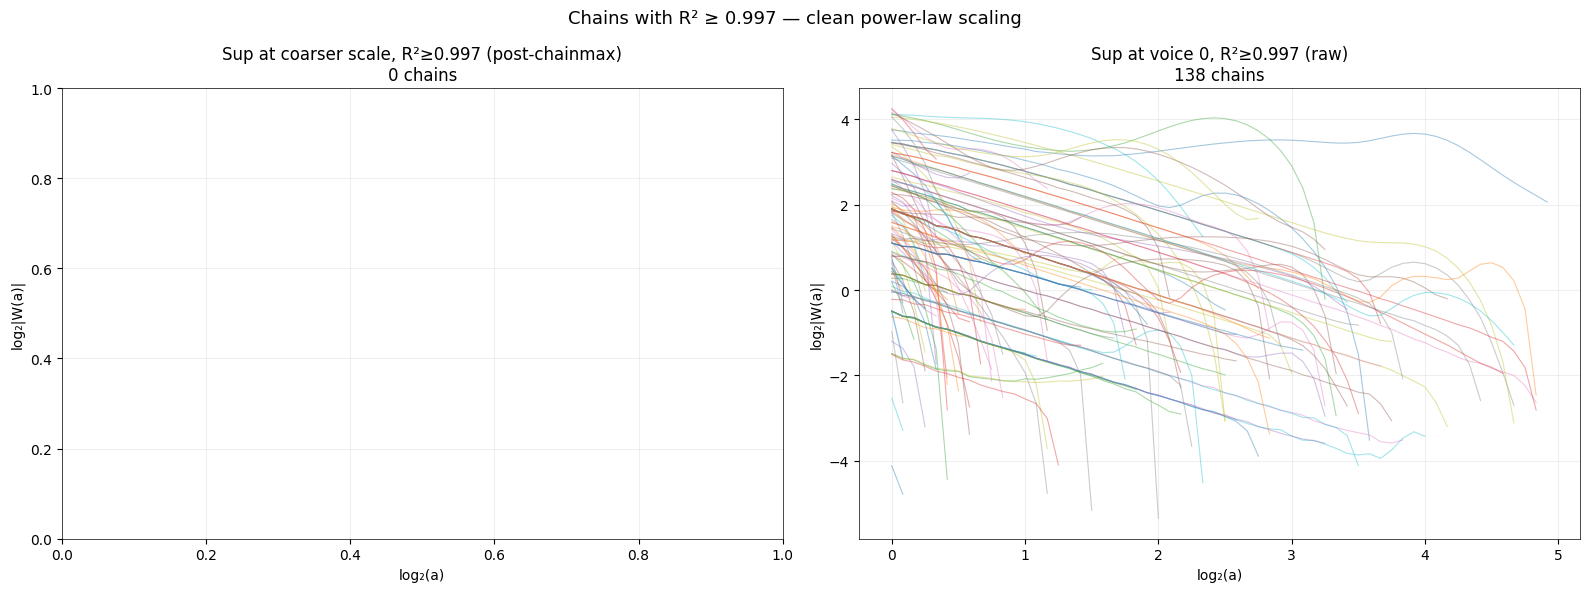

In [197]:
# Chains with R² > 0.95 from both groups
# High R² = clean power-law scaling, likely real singularities
# Low R² = noisy / non-power-law, likely artifacts or masked
import matplotlib.pyplot as plt
import numpy as np

R2_THRESH = 0.997

# Filter sup-at-coarser group (post-chainmax)
good_pos = [(la, lw) for (la, lw), r2 in zip(sup_coarse, r2_pos) if r2 >= R2_THRESH]
# Filter sup-at-finest group (raw)
good_neg = [(la, lw) for (la, lw), r2 in zip(sup_finest, r2_neg) if r2 >= R2_THRESH]

print(f'R² ≥ {R2_THRESH}:')
print(f'  Sup coarser: {len(good_pos)} / {len(sup_coarse)} chains')
print(f'  Sup finest:  {len(good_neg)} / {len(sup_finest)} chains')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

ax = axes[0]
for log2_a, log2_w in good_pos:
    ax.plot(log2_a, log2_w, '-', alpha=0.4, lw=0.8)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'Sup at coarser scale, R²≥{R2_THRESH} (post-chainmax)\n{len(good_pos)} chains')
ax.grid(True, alpha=0.2)

ax = axes[1]
for log2_a, log2_w in good_neg:
    ax.plot(log2_a, log2_w, '-', alpha=0.4, lw=0.8)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'Sup at voice 0, R²≥{R2_THRESH} (raw)\n{len(good_neg)} chains')
ax.grid(True, alpha=0.2)

plt.suptitle(f'Chains with R² ≥ {R2_THRESH} — clean power-law scaling', fontsize=13)
plt.tight_layout()
plt.show()

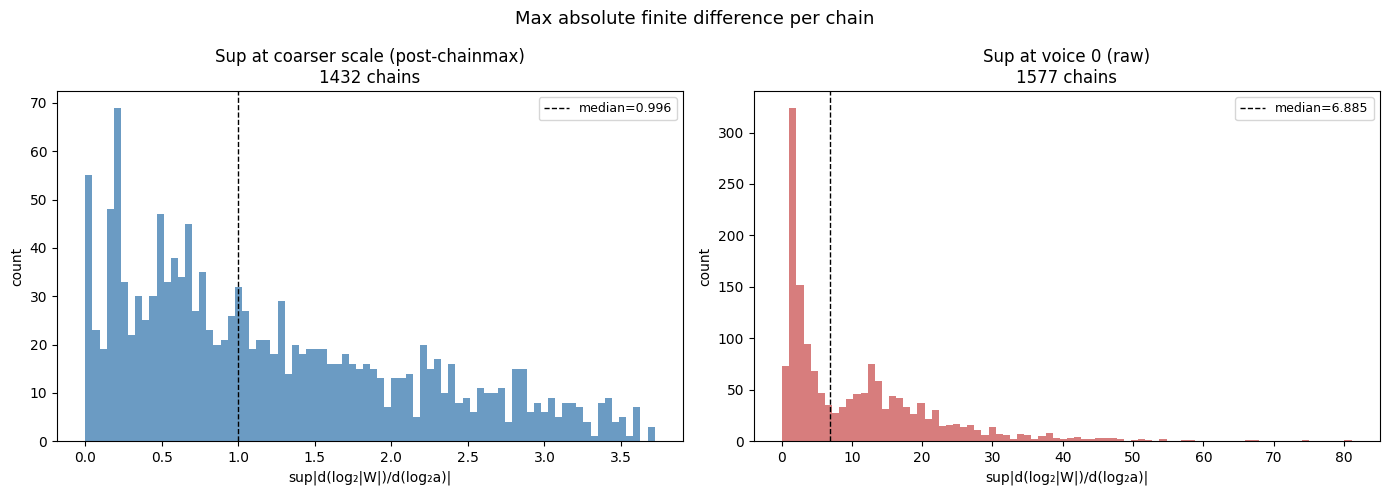

In [193]:
# Histograms of sup|finite difference| for each group
# sup of |d(log₂|W|)/d(log₂a)| per chain — measures the maximum
# local rate of change along the chain
import matplotlib.pyplot as plt
import numpy as np

sup_fd_pos = []
for log2_a, log2_w in sup_coarse:
    if len(log2_a) < 2:
        continue
    deriv = np.diff(log2_w) / np.diff(log2_a)
    sup_fd_pos.append(np.max(np.abs(deriv)))

sup_fd_neg = []
for log2_a, log2_w in sup_finest:
    if len(log2_a) < 2:
        continue
    deriv = np.diff(log2_w) / np.diff(log2_a)
    sup_fd_neg.append(np.max(np.abs(deriv)))

sup_fd_pos = np.array(sup_fd_pos)
sup_fd_neg = np.array(sup_fd_neg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(sup_fd_pos, bins=80, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(np.median(sup_fd_pos), color='k', ls='--', lw=1, label=f'median={np.median(sup_fd_pos):.3f}')
ax.set_xlabel('sup|d(log₂|W|)/d(log₂a)|')
ax.set_ylabel('count')
ax.set_title(f'Sup at coarser scale (post-chainmax)\n{len(sup_fd_pos)} chains')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(sup_fd_neg, bins=80, color='indianred', alpha=0.8, edgecolor='none')
ax.axvline(np.median(sup_fd_neg), color='k', ls='--', lw=1, label=f'median={np.median(sup_fd_neg):.3f}')
ax.set_xlabel('sup|d(log₂|W|)/d(log₂a)|')
ax.set_ylabel('count')
ax.set_title(f'Sup at voice 0 (raw)\n{len(sup_fd_neg)} chains')
ax.legend(fontsize=9)

plt.suptitle('Max absolute finite difference per chain', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Remove chains from the surviving (sup-at-coarser) group whose
# post-chainmax slope is h ≈ 0 (within H_ZERO_TOL).
# These slipped through chainmax with a tiny positive slope but
# are effectively flat — not real singularities.

H_ZERO_TOL = 0.002

n_scales_total = N_OCT * N_VOICE
n_finest = len(extrep_abs[0])

# Identify chains with |h| < H_ZERO_TOL from post-chainmax slope
remove_mask = np.zeros(n_finest, dtype=bool)
h_zero_chains_raw = []  # save raw log-log for plotting

for fi in range(n_finest):
    log2_a_list = []
    cm_list = []
    raw_list = []
    cs, ci = 0, fi
    while cs < n_scales_total and ci != -1:
        log2_a_list.append(np.log2(scales[cs]))
        eidx = extrep_idx[cs][ci]
        raw_list.append(np.log2(abs(coeffs[cs, eidx]) + 1e-300))
        cm_list.append(np.log2(abs(extrep_ord[cs][ci]) + 1e-300))
        ci = coarser_links[cs][ci]
        cs += 1

    if len(log2_a_list) < 3:
        continue

    log2_a = np.array(log2_a_list)
    cm_log2w = np.array(cm_list)
    h_cm = np.polyfit(log2_a, cm_log2w, 1)[0]

    if abs(h_cm) < H_ZERO_TOL:
        remove_mask[fi] = True
        h_zero_chains_raw.append((log2_a, np.array(raw_list)))

n_h_zero = int(remove_mask.sum())
print(f'Chains with |h_chainmax| < {H_ZERO_TOL}: {n_h_zero}')

# Remove from extrep
remove_set = [set() for _ in range(len(extrep_abs))]
for fi in range(n_finest):
    if not remove_mask[fi]:
        continue
    cs, ci = 0, fi
    while cs < len(extrep_abs) and ci != -1:
        remove_set[cs].add(ci)
        ci = coarser_links[cs][ci]
        cs += 1

n_removed_total = 0
old_to_new = []
for s in range(len(extrep_abs)):
    n_old = len(extrep_abs[s])
    to_remove = remove_set[s]
    n_removed_total += len(to_remove)

    if len(to_remove) == 0:
        old_to_new.append({i: i for i in range(n_old)})
        continue

    keep_mask = np.array([i not in to_remove for i in range(n_old)])
    mapping = {}
    new_idx = 0
    for old_idx in range(n_old):
        if keep_mask[old_idx]:
            mapping[old_idx] = new_idx
            new_idx += 1
        else:
            mapping[old_idx] = -1
    old_to_new.append(mapping)

    extrep_abs[s] = extrep_abs[s][keep_mask]
    extrep_ord[s] = extrep_ord[s][keep_mask]
    extrep_idx[s] = extrep_idx[s][keep_mask]

for s in range(len(coarser_links)):
    n_cur = len(extrep_abs[s])
    new_cl = np.full(n_cur, -1, dtype=int)
    new_fl = np.full(n_cur, -1, dtype=int)

    old_cl = coarser_links[s]
    old_fl = finer_links[s]
    mapping_cur = old_to_new[s]
    mapping_coarser = old_to_new[s + 1] if s + 1 < len(old_to_new) else {}
    mapping_finer = old_to_new[s - 1] if s > 0 else {}

    for old_idx, new_idx in mapping_cur.items():
        if new_idx == -1:
            continue
        if old_idx < len(old_cl):
            old_target = old_cl[old_idx]
            if old_target != -1 and old_target in mapping_coarser:
                new_cl[new_idx] = mapping_coarser[old_target]
            else:
                new_cl[new_idx] = -1
        if old_idx < len(old_fl):
            old_target = old_fl[old_idx]
            if old_target != -1 and old_target in mapping_finer:
                new_fl[new_idx] = mapping_finer[old_target]
            else:
                new_fl[new_idx] = -1

    coarser_links[s] = new_cl
    finer_links[s] = new_fl

n_remaining = sum(len(a) for a in extrep_abs)
print(f'Removed {n_h_zero} h≈0 chains ({n_removed_total} extrema)')
print(f'Remaining extrema: {n_remaining}')

# Plot the three groups
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Re-walk surviving chains for the h>0 group
surviving = []
for fi in range(len(extrep_abs[0])):
    log2_a_list = []
    cm_list = []
    cs, ci = 0, fi
    while cs < n_scales_total and ci != -1:
        log2_a_list.append(np.log2(scales[cs]))
        cm_list.append(np.log2(abs(extrep_ord[cs][ci]) + 1e-300))
        ci = coarser_links[cs][ci]
        cs += 1
    if len(log2_a_list) >= 2:
        surviving.append((np.array(log2_a_list), np.array(cm_list)))

ax = axes[0]
for log2_a, log2_w in surviving:
    ax.plot(log2_a, log2_w, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'h > 0 (post-chainmax)\n{len(surviving)} chains')
ax.grid(True, alpha=0.2)

ax = axes[1]
for log2_a, raw_log2w in h_zero_chains_raw:
    ax.plot(log2_a, raw_log2w, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'h ≈ 0 (raw, |h|<{H_ZERO_TOL})\n{len(h_zero_chains_raw)} chains')
ax.grid(True, alpha=0.2)

ax = axes[2]
for log2_a, log2_w in sup_finest:
    ax.plot(log2_a, log2_w, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'h < 0, sup at voice 0 (raw)\n{len(sup_finest)} chains')
ax.grid(True, alpha=0.2)

plt.suptitle('Three chain groups: h>0 | h≈0 | h<0', fontsize=13)
plt.tight_layout()
plt.show()

Error: NameError: name 'pre_chainmax_chains' is not defined
[31m---------------------------------------------------------------------------[39m
[31mNameError[39m                                 Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[118][39m[32m, line 15[39m
[32m     13[39m [38;5;66;03m# Left panel: log₂|W(a)| vs log₂(a) for each chain (raw, pre-chainmax)[39;00m
[32m     14[39m ax = axes[[32m0[39m]
[32m---> [39m[32m15[39m [38;5;28;01mfor[39;00m pos, sv, sign, vals [38;5;129;01min[39;00m [43mpre_chainmax_chains[49m:
[32m     16[39m     log2_w = np.log2(np.abs(np.array(vals)) + [32m1e-300[39m)
[32m     17[39m     ax.plot(sv, log2_w, [33m'[39m[33m-[39m[33m'[39m, alpha=[32m0.3[39m, lw=[32m0.6[39m)

[31mNameError[39m: name 'pre_chainmax_chains' is not defined

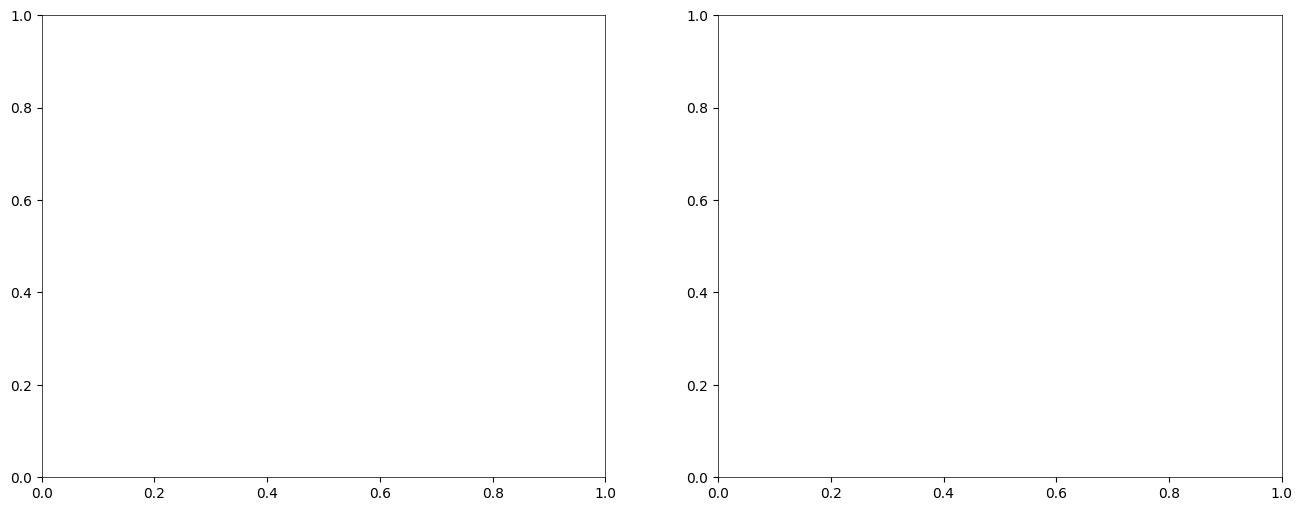

In [ ]:
# Hölder exponent visualization: log|W(a)| vs log₂(a) for each chain
# Plot finite difference derivative d(log₂|W|)/d(log₂a) for each chain
# BEFORE chainmax — raw CWT modulus values along skeleton lines
# The derivative at each scale gives the local Hölder exponent estimate

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Left panel: log₂|W(a)| vs log₂(a) for each chain (raw, pre-chainmax)
ax = axes[0]
for pos, sv, sign, vals in pre_chainmax_chains:
    log2_w = np.log2(np.abs(np.array(vals)) + 1e-300)
    ax.plot(sv, log2_w, '-', alpha=0.3, lw=0.6)
ax.set_xlabel('log₂(a)')
ax.set_ylabel('log₂|W(a)|')
ax.set_title(f'Raw CWT along chains (pre-chainmax)\n{len(pre_chainmax_chains)} chains')
ax.grid(True, alpha=0.2)

# Right panel: finite difference derivative d(log₂|W|)/d(log₂a)
ax = axes[1]
for pos, sv, sign, vals in pre_chainmax_chains:
    log2_w = np.log2(np.abs(np.array(vals)) + 1e-300)
    log2_a = np.array(sv)
    if len(log2_a) < 2:
        continue
    # Finite difference: Δ(log₂|W|) / Δ(log₂a)
    d_log2w = np.diff(log2_w)
    d_log2a = np.diff(log2_a)
    deriv = d_log2w / d_log2a
    # Plot at midpoints
    mid_a = 0.5 * (log2_a[:-1] + log2_a[1:])
    ax.plot(mid_a, deriv, '-', alpha=0.3, lw=0.6)

ax.set_xlabel('log₂(a)')
ax.set_ylabel('d(log₂|W|) / d(log₂a)')
ax.set_title('Finite difference derivative (local Hölder exponent)\npre-chainmax')
ax.grid(True, alpha=0.2)
ax.axhline(0, color='k', lw=0.5, ls='-')

plt.tight_layout()
plt.show()

# Summary statistics
n_chains = len(pre_chainmax_chains)
chain_lengths = [len(sv) for _, sv, _, _ in pre_chainmax_chains]
print(f'Chains: {n_chains}, length range: [{min(chain_lengths)}, {max(chain_lengths)}]')
print(f'Mean chain length: {np.mean(chain_lengths):.1f} scales')

In [ ]:
# Cell 17b: Cone-of-influence chain filtering
# Remove chains whose finest-scale position falls within the COI
# of the coarsest scale (boundary region where edge effects dominate).

REMOVE_COI_CHAINS = False  # <-- toggle this

if REMOVE_COI_CHAINS:
    # COI boundary from the coarsest scale's valid range
    coarsest_scale_idx = len(scales) - 1
    coi_left_idx, coi_right_idx = valid_ranges[coarsest_scale_idx]
    coi_left_pos = coi_left_idx * dx_signal   # convert index to position
    coi_right_pos = coi_right_idx * dx_signal

    # Find which finest-scale extrema are in the COI
    # (position < coi_left_pos or position > coi_right_pos)
    n_finest = len(extrep_abs[0])
    coi_mask = np.zeros(n_finest, dtype=bool)  # True = in COI, remove
    for fi in range(n_finest):
        pos = extrep_abs[0][fi]
        if pos < coi_left_pos or pos > coi_right_pos:
            coi_mask[fi] = True

    # Walk each COI chain from finest to coarsest, collecting (scale, index) to remove
    remove_set = []  # list of sets, one per scale
    for s in range(len(extrep_abs)):
        remove_set.append(set())

    for fi in range(n_finest):
        if not coi_mask[fi]:
            continue
        cs, ci = 0, fi
        while cs < len(extrep_abs) and ci != -1:
            remove_set[cs].add(ci)
            ci = coarser_links[cs][ci]
            cs += 1

    # Rebuild extrep arrays, removing marked extrema
    # Build index mapping (old -> new) per scale for link fixup
    n_removed_total = 0
    old_to_new = []  # per scale
    for s in range(len(extrep_abs)):
        n_old = len(extrep_abs[s])
        to_remove = remove_set[s]
        n_removed_total += len(to_remove)

        if len(to_remove) == 0:
            old_to_new.append({i: i for i in range(n_old)})
            continue

        keep_mask = np.array([i not in to_remove for i in range(n_old)])
        mapping = {}
        new_idx = 0
        for old_idx in range(n_old):
            if keep_mask[old_idx]:
                mapping[old_idx] = new_idx
                new_idx += 1
            else:
                mapping[old_idx] = -1
        old_to_new.append(mapping)

        extrep_abs[s] = extrep_abs[s][keep_mask]
        extrep_ord[s] = extrep_ord[s][keep_mask]
        extrep_idx[s] = extrep_idx[s][keep_mask]

    # Fix up coarser_links and finer_links with new indices
    for s in range(len(coarser_links)):
        n_cur = len(extrep_abs[s])
        new_cl = np.full(n_cur, -1, dtype=int)
        new_fl = np.full(n_cur, -1, dtype=int)

        old_cl = coarser_links[s]
        old_fl = finer_links[s]
        mapping_cur = old_to_new[s]
        mapping_coarser = old_to_new[s + 1] if s + 1 < len(old_to_new) else {}
        mapping_finer = old_to_new[s - 1] if s > 0 else {}

        for old_idx, new_idx in mapping_cur.items():
            if new_idx == -1:
                continue
            # Coarser link
            if old_idx < len(old_cl):
                old_target = old_cl[old_idx]
                if old_target != -1 and old_target in mapping_coarser:
                    new_cl[new_idx] = mapping_coarser[old_target]
                else:
                    new_cl[new_idx] = -1
            # Finer link
            if old_idx < len(old_fl):
                old_target = old_fl[old_idx]
                if old_target != -1 and old_target in mapping_finer:
                    new_fl[new_idx] = mapping_finer[old_target]
                else:
                    new_fl[new_idx] = -1

        coarser_links[s] = new_cl
        finer_links[s] = new_fl

    n_coi_chains = int(coi_mask.sum())
    n_remaining = sum(len(a) for a in extrep_abs)
    print(f'COI filtering: removed {n_coi_chains} chains ({n_removed_total} extrema across all scales)')
    print(f'  COI boundary (coarsest scale): position [{coi_left_pos:.4f}, {coi_right_pos:.4f}]')
    print(f'  COI boundary (indices): [{coi_left_idx}, {coi_right_idx}] of {SIZE}')
    print(f'  Remaining extrema: {n_remaining}')

    # Re-trace surviving chains for visualization
    post_coi_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, N_OCT * N_VOICE)
    print(f'  Surviving chains after COI filter: {len(post_coi_chains)}')

    # Visualization: show COI boundaries on maxima lines
    import matplotlib as mpl
    N_COLORS = 14
    fig, ax = plt.subplots(figsize=(14, 6))
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

    # COI shading
    ax.axvspan(0, coi_left_pos, color='red', alpha=0.08, label='COI (removed)')
    ax.axvspan(coi_right_pos, 1.0, color='red', alpha=0.08)

    # Surviving chains colored by log2|ordinate|
    if len(post_coi_chains) > 0:
        all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300)
                                        for _, _, _, vals in post_coi_chains])
        vmin, vmax = np.percentile(all_log2_vals, [0, 100])
        boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
        norm_c = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
        cmap_c = lastwave_colormap(N_COLORS)
        for pos, sv, sign, vals in post_coi_chains:
            log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
            for j in range(len(pos) - 1):
                ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap_c(norm_c(log2_v[j])), lw=1)

    ax.set_xlabel('Position')
    ax.set_ylabel('log₂(scale)')
    ax.set_title(f'{analysis_label} — {len(post_coi_chains)} chains after COI filter '
                 f'({n_coi_chains} removed)')
    ax.legend(fontsize=8, loc='upper right')
    ax.margins(0)
    plt.tight_layout()
    plt.show()
else:
    print('COI filtering: disabled (REMOVE_COI_CHAINS = False)')


COI filtering: disabled (REMOVE_COI_CHAINS = False)


Best internal R²:
  Range: log2(a) = [5.30, 7.10]  (1.8 octaves)
  Mean R² = 0.995240

Current setting: LOG2_A_MIN=0.0, LOG2_A_MAX=9


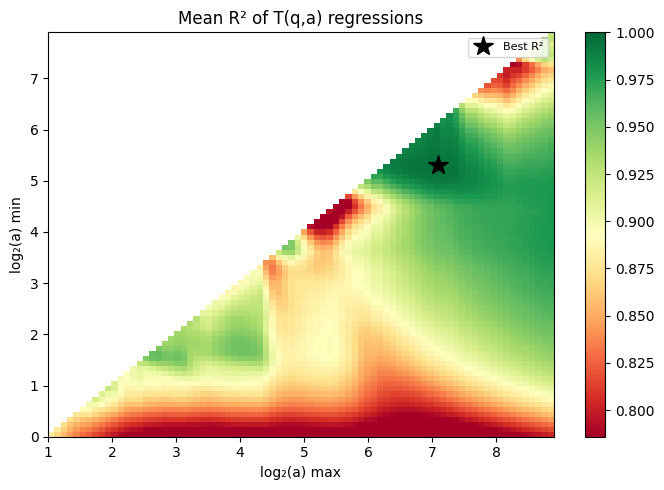

In [ ]:
# Cell 20: Optimal regression range search
# Grid search over (log2_a_min, log2_a_max) to find the range that:
#   1. Best internal R² — how linear are T(q,a) vs log2(a) within the range
#   2. Best theory fit — how close are the resulting tau(q) to analytical values
#   3. Best D(h) spectrum — per-q D(h) match and spectrum width agreement

LOG2_A_MIN = 0.0
LOG2_A_MAX = 9

from wtmm.partition import pf_get_T, pf_get_H, pf_get_D
from wtmm.spectra import compute_spectra

log2_a = pf['log2_a']
n_voice = pf['n_voice']
log2_a0 = np.log2(pf['a_min'])
dx = 1.0 / n_voice
max_idx = pf['index_max']

# Build grid: all (min, max) pairs with at least 1 octave separation
min_octave_span = 1.0
grid_step = dx  # step in log2(a) units

lo_vals = np.arange(log2_a0, log2_a0 + dx * max_idx - min_octave_span + dx/2, grid_step)
hi_vals = np.arange(log2_a0 + min_octave_span, log2_a0 + dx * max_idx + dx/2, grid_step)

q_array = pf['q_list']
n_q = len(q_array)

# Precompute T(q,a), H(q,a), D(q,a) for all q
T_all = np.zeros((n_q, max_idx + 1))
H_all = np.zeros((n_q, max_idx + 1))
D_all = np.zeros((n_q, max_idx + 1))
for qi in range(n_q):
    T_all[qi] = pf_get_T(pf, qi, 'extensive')[:max_idx + 1]
    H_all[qi] = pf_get_H(pf, qi, 'extensive')[:max_idx + 1]
    D_all[qi] = pf_get_D(pf, qi, q_array[qi], 'extensive')[:max_idx + 1]

# Theory values at the partition function q values (if available)
is_multifractal_theory = has_theory and theory_h is not None and len(theory_h) > 1
if has_theory:
    tau_theory_at_q = np.interp(q_array, theory_q, theory_tau)
if is_multifractal_theory:
    h_theory_at_q = np.interp(q_array, theory_q, theory_h)
    D_theory_at_q = np.interp(q_array, theory_q, theory_D)
    # Theory spectrum width: range of h where D > 0
    _tmask = theory_D > 0
    theory_width = theory_h[_tmask].max() - theory_h[_tmask].min() if _tmask.any() else 0.0

results = []  # (lo, hi, mean_r2, tau_rmse, dh_score)

for lo in lo_vals:
    idx_lo = int(round((lo - log2_a0) / dx))
    idx_lo = max(idx_lo, 0)
    for hi in hi_vals:
        if hi - lo < min_octave_span - 1e-9:
            continue
        idx_hi = int(round((hi - log2_a0) / dx))
        idx_hi = min(idx_hi, max_idx)
        if idx_hi - idx_lo < 2:
            continue

        vidx = np.arange(idx_lo, idx_hi + 1)
        x = log2_a0 + dx * vidx

        # Compute R² and slopes for T, H, D
        r2_list = []
        tau_fit = np.full(n_q, np.nan)
        h_fit = np.full(n_q, np.nan)
        d_fit = np.full(n_q, np.nan)
        for qi in range(n_q):
            y_T = T_all[qi, vidx]
            y_H = H_all[qi, vidx]
            y_D = D_all[qi, vidx]
            if not np.all(np.isfinite(y_T)):
                continue
            slope_T, intercept_T = np.polyfit(x, y_T, 1)
            tau_fit[qi] = slope_T
            y_pred = slope_T * x + intercept_T
            ss_res = np.sum((y_T - y_pred)**2)
            ss_tot = np.sum((y_T - np.mean(y_T))**2)
            r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
            r2_list.append(r2)
            if np.all(np.isfinite(y_H)):
                h_fit[qi] = np.polyfit(x, y_H, 1)[0]
            if np.all(np.isfinite(y_D)):
                d_fit[qi] = np.polyfit(x, y_D, 1)[0]

        if len(r2_list) == 0:
            continue
        mean_r2 = np.mean(r2_list)

        # Theory tau RMSE
        if has_theory:
            vm = np.isfinite(tau_fit)
            tau_rmse = np.sqrt(np.mean((tau_fit[vm] - tau_theory_at_q[vm])**2)) if vm.any() else np.inf
        else:
            tau_rmse = np.nan

        # D(h) spectrum score: per-q comparison of (h(q), D(q)) pairs
        if is_multifractal_theory:
            vm = np.isfinite(h_fit) & np.isfinite(d_fit)
            if vm.sum() >= 3:
                # Per-q h(q) RMSE
                h_rmse = np.sqrt(np.mean((h_fit[vm] - h_theory_at_q[vm])**2))
                # Per-q D(q) RMSE
                d_rmse = np.sqrt(np.mean((d_fit[vm] - D_theory_at_q[vm])**2))
                # Spectrum width comparison
                wtmm_width = h_fit[vm].max() - h_fit[vm].min()
                width_error = abs(wtmm_width - theory_width) / max(theory_width, 1e-10)
                # Combined score: geometric mean of normalized errors
                dh_score = np.sqrt(h_rmse**2 + d_rmse**2 + (width_error * 0.5)**2)
            else:
                dh_score = np.inf
        else:
            dh_score = np.nan

        results.append((lo, hi, mean_r2, tau_rmse, dh_score))

results = np.array(results)

# --- Find best ranges ---
# 1. Best R²
best_r2_idx = np.argmax(results[:, 2])
best_r2 = results[best_r2_idx]
print(f'Best internal R²:')
print(f'  Range: log2(a) = [{best_r2[0]:.2f}, {best_r2[1]:.2f}]  '
      f'({best_r2[1]-best_r2[0]:.1f} octaves)')
print(f'  Mean R² = {best_r2[2]:.6f}')

if has_theory:
    # 2. Best theory tau fit
    best_thy_idx = np.argmin(results[:, 3])
    best_thy = results[best_thy_idx]
    print(f'\nBest tau(q) theory fit:')
    print(f'  Range: log2(a) = [{best_thy[0]:.2f}, {best_thy[1]:.2f}]  '
          f'({best_thy[1]-best_thy[0]:.1f} octaves)')
    print(f'  tau(q) RMSE = {best_thy[3]:.6f}, R² = {best_thy[2]:.6f}')

    # 3. Combined: best theory fit among ranges with R² > 0.99
    good_r2_mask = results[:, 2] > 0.99
    if good_r2_mask.any():
        good_results = results[good_r2_mask]
        best_combo_idx = np.argmin(good_results[:, 3])
        best_combo = good_results[best_combo_idx]
        print(f'\nBest combined (R²>0.99, then min tau RMSE):')
        print(f'  Range: log2(a) = [{best_combo[0]:.2f}, {best_combo[1]:.2f}]  '
              f'({best_combo[1]-best_combo[0]:.1f} octaves)')
        print(f'  tau(q) RMSE = {best_combo[3]:.6f}, R² = {best_combo[2]:.6f}')

if is_multifractal_theory:
    # 4. Best D(h) spectrum match
    best_dh_idx = np.argmin(results[:, 4])
    best_dh = results[best_dh_idx]
    print(f'\nBest D(h) spectrum fit:')
    print(f'  Range: log2(a) = [{best_dh[0]:.2f}, {best_dh[1]:.2f}]  '
          f'({best_dh[1]-best_dh[0]:.1f} octaves)')
    print(f'  D(h) score = {best_dh[4]:.6f} (lower=better)')
    print(f'  R² = {best_dh[2]:.6f}, tau RMSE = {best_dh[3]:.6f}')

    # Best D(h) among good R² ranges
    if good_r2_mask.any():
        best_dh_combo_idx = np.argmin(good_results[:, 4])
        best_dh_combo = good_results[best_dh_combo_idx]
        print(f'\nBest D(h) (R²>0.99):')
        print(f'  Range: log2(a) = [{best_dh_combo[0]:.2f}, {best_dh_combo[1]:.2f}]  '
              f'({best_dh_combo[1]-best_dh_combo[0]:.1f} octaves)')
        print(f'  D(h) score = {best_dh_combo[4]:.6f}, R² = {best_dh_combo[2]:.6f}')

print(f'\nCurrent setting: LOG2_A_MIN={LOG2_A_MIN}, LOG2_A_MAX={LOG2_A_MAX}')

# --- Visualization ---
n_panels = 1 + (1 if has_theory else 0) + (1 if is_multifractal_theory else 0)
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

# Reshape for heatmaps
lo_unique = np.sort(np.unique(results[:, 0]))
hi_unique = np.sort(np.unique(results[:, 1]))
lo_to_i = {v: i for i, v in enumerate(lo_unique)}
hi_to_j = {v: j for j, v in enumerate(hi_unique)}

r2_grid = np.full((len(lo_unique), len(hi_unique)), np.nan)
rmse_grid = np.full((len(lo_unique), len(hi_unique)), np.nan)
dh_grid = np.full((len(lo_unique), len(hi_unique)), np.nan)
for row in results:
    lo, hi, r2, rmse, dh = row
    i, j = lo_to_i[lo], hi_to_j[hi]
    r2_grid[i, j] = r2
    rmse_grid[i, j] = rmse
    dh_grid[i, j] = dh

extent = [hi_unique[0], hi_unique[-1], lo_unique[0], lo_unique[-1]]
panel = 0

# Panel 1: R² heatmap
ax = axes[panel]
im = ax.imshow(r2_grid, aspect='auto', origin='lower', extent=extent,
               cmap='RdYlGn', vmin=np.nanpercentile(r2_grid, 5), vmax=1.0)
ax.plot(best_r2[1], best_r2[0], 'k*', markersize=15, label='Best R²')
ax.set_xlabel('log₂(a) max'); ax.set_ylabel('log₂(a) min')
ax.set_title('Mean R² of T(q,a) regressions')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax)
panel += 1

# Panel 2: tau(q) RMSE
if has_theory:
    ax = axes[panel]
    vmax_rmse = np.nanpercentile(rmse_grid, 90)
    im2 = ax.imshow(rmse_grid, aspect='auto', origin='lower', extent=extent,
                    cmap='RdYlGn_r', vmin=0, vmax=vmax_rmse)
    ax.plot(best_thy[1], best_thy[0], 'k*', markersize=15, label='Best τ(q)')
    if good_r2_mask.any():
        ax.plot(best_combo[1], best_combo[0], 'b^', markersize=12, label='Best combo')
    ax.set_xlabel('log₂(a) max'); ax.set_ylabel('log₂(a) min')
    ax.set_title('τ(q) RMSE vs theory')
    ax.legend(fontsize=8)
    plt.colorbar(im2, ax=ax)
    panel += 1

# Panel 3: D(h) spectrum score
if is_multifractal_theory:
    ax = axes[panel]
    vmax_dh = np.nanpercentile(dh_grid, 90)
    im3 = ax.imshow(dh_grid, aspect='auto', origin='lower', extent=extent,
                    cmap='RdYlGn_r', vmin=0, vmax=vmax_dh)
    ax.plot(best_dh[1], best_dh[0], 'k*', markersize=15, label='Best D(h)')
    if good_r2_mask.any():
        ax.plot(best_dh_combo[1], best_dh_combo[0], 'b^', markersize=12, label='Best D(h) R²>0.99')
    ax.set_xlabel('log₂(a) max'); ax.set_ylabel('log₂(a) min')
    ax.set_title('D(h) spectrum score\n(per-q h & D RMSE + width)')
    ax.legend(fontsize=8)
    plt.colorbar(im3, ax=ax)

plt.tight_layout()
plt.show()

Partition function computed in 0.023s, up to scale index 89
Extrema per scale (sample): [3686 3561 3454 3337 3233]...[15 15 14 11  9]


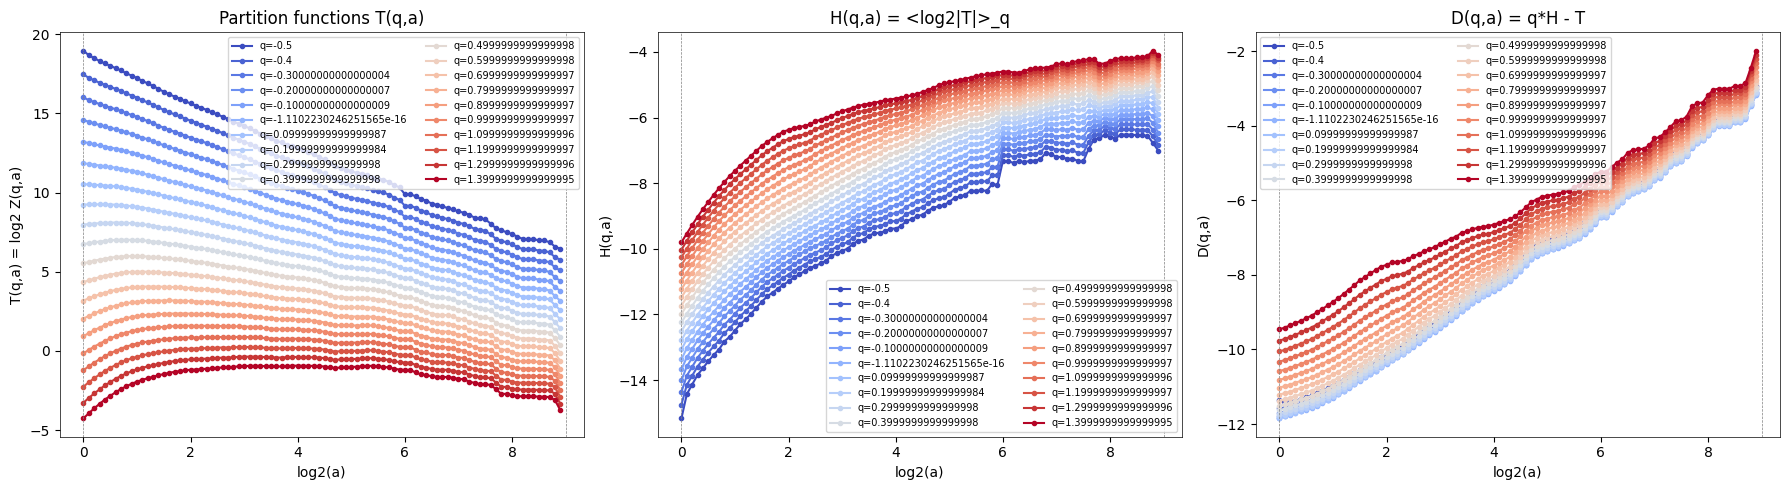

Gray dashed lines show regression range [log2(a)=0 to 9]


In [ ]:
# Cell 18: Partition function — now imported from wtmm package
from wtmm.partition import compute_partition_function, pf_get_T, pf_get_H, pf_get_D
LOG2_A_MIN = 0
LOG2_A_MAX = 9

# Compute partition function
q_list = np.arange(-.5, 1.5, .1)  #[ -.5, -.25, 0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75,  2, 3]

t0 = time.time()
pf = compute_partition_function(extrep_ord, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN, q_list=q_list)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf["index_max"]}')
print(f'Extrema per scale (sample): {pf["n_ext"][:5]}...{pf["n_ext"][-5:]}')

# Plot T(q,a) = log2(Z(q,a)) vs log2(a)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
log2_a = pf['log2_a']
valid = slice(0, pf['index_max'] + 1)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_list)))

# T(q,a)
ax = axes[0]
for i, q in enumerate(pf['q_list']):
    y = pf_get_T(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) = log2 Z(q,a)')
ax.set_title('Partition functions T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)

# H(q,a)
ax = axes[1]
for i, q in enumerate(pf['q_list']):
    y = pf_get_H(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)

# D(q,a)
ax = axes[2]
for i, q in enumerate(pf['q_list']):
    y = pf_get_D(pf, i, q)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(LOG2_A_MIN, color='gray', ls='--', lw=0.5)
ax.axvline(LOG2_A_MAX, color='gray', ls='--', lw=0.5)

plt.tight_layout()
plt.show()
print(f'Gray dashed lines show regression range [log2(a)={LOG2_A_MIN} to {LOG2_A_MAX}]')


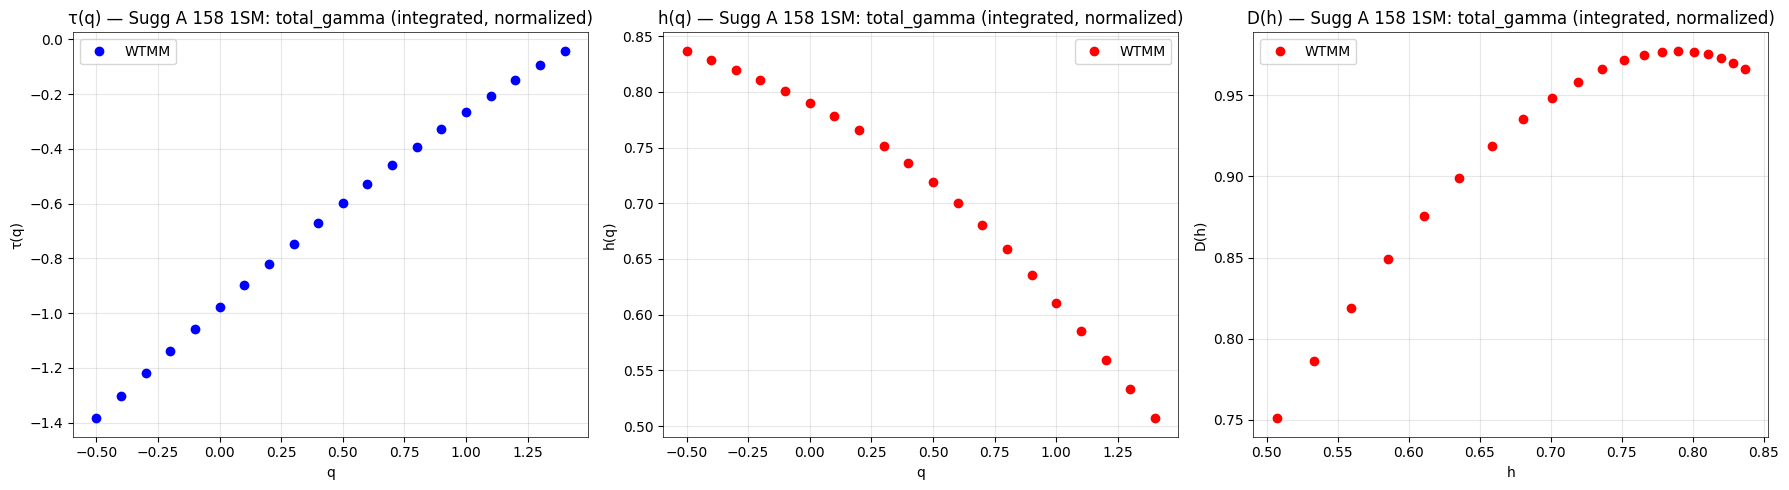


Sugg A 158 1SM: total_gamma (integrated, normalized): no theoretical spectrum available
WTMM h(q) range: [0.5070, 0.8369]


In [ ]:
# Cell 19: tau(q), h(q), D(h) spectrum — now imported from wtmm package
from wtmm.spectra import compute_spectra

# Compute spectra
spectra = compute_spectra(pf, log2_a_min=LOG2_A_MIN, log2_a_max=LOG2_A_MAX)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

is_monofractal = has_theory and theory_h is not None and len(theory_h) == 1

# 1. tau(q)
ax = axes[0]
if has_theory:
    ax.plot(theory_q, theory_tau, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('\u03c4(q)')
ax.set_title(f'\u03c4(q) — {analysis_label}')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. h(q)
ax = axes[1]
if has_theory and not is_monofractal:
    ax.plot(theory_q, theory_h, 'k-', label='Theory', linewidth=1)
elif is_monofractal:
    ax.axhline(theory_h[0], color='k', ls='--', lw=1, label=f'Theory h*={theory_h[0]:.3f}')
ax.plot(spectra['q_list'], spectra['h_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title(f'h(q) — {analysis_label}')
ax.legend()
ax.grid(True, alpha=0.3)
if has_theory and not is_monofractal:
    h_pad = 0.15 * (theory_h.max() - theory_h.min())
    ax.set_ylim(theory_h.min() - h_pad, theory_h.max() + h_pad)

# 3. D(h) singularity spectrum
ax = axes[2]
if has_theory and not is_monofractal:
    mask = theory_D > -0.5
    ax.plot(theory_h[mask], theory_D[mask], 'k-', label='Theory', linewidth=1)
elif is_monofractal:
    ax.plot(theory_h[0], theory_D[0], 'k*', markersize=15, label=f'Theory (h*={theory_h[0]:.3f})')
ax.plot(spectra['h_q'], spectra['D_q'], 'ro', markersize=6, linestyle='none', label='WTMM')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title(f'D(h) — {analysis_label}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison
if has_theory and not is_monofractal:
    from wtmm.spectra import theoretical_devil_staircase
    # Interpolate theory at WTMM q values for comparison
    tau_theory_q = np.interp(spectra['q_list'], theory_q, theory_tau)
    h_theory_q = np.interp(spectra['q_list'], theory_q, theory_h)
    print(f'\n{analysis_label}: theory vs WTMM comparison')
    print(f'h range: [{h_theory_q.min():.3f}, {h_theory_q.max():.3f}]')
    print('\nq\t \u03c4_WTMM\t \u03c4_theory\t diff\t\t h_WTMM\t\t h_theory')
    for i, q_val in enumerate(spectra['q_list']):
        print(f'{q_val:5.1f}\t {spectra["tau_q"][i]:8.4f}\t {tau_theory_q[i]:8.4f}\t {spectra["tau_q"][i]-tau_theory_q[i]:+.4f}'
              f'\t {spectra["h_q"][i]:8.4f}\t {h_theory_q[i]:8.4f}')
elif is_monofractal:
    print(f'\n{analysis_label}: monofractal h* = {theory_h[0]:.4f}')
    print(f'WTMM h(q) range: [{spectra["h_q"].min():.4f}, {spectra["h_q"].max():.4f}]')
    print(f'WTMM h(q) mean:  {spectra["h_q"].mean():.4f}')
else:
    print(f'\n{analysis_label}: no theoretical spectrum available')
    print(f'WTMM h(q) range: [{spectra["h_q"].min():.4f}, {spectra["h_q"].max():.4f}]')


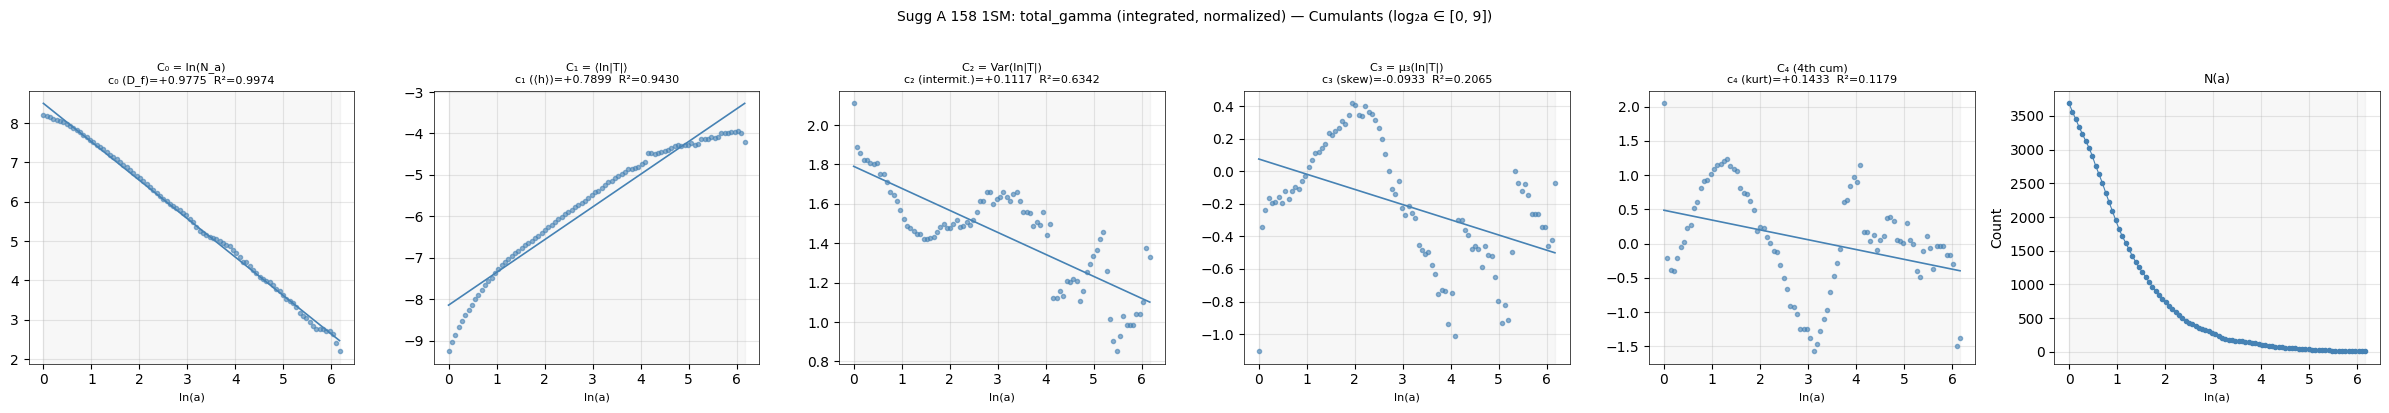

=== Cumulant coefficients ===
                c₀ (D_f) = +0.9775 ± 0.0054   R² = 0.997366
                c₁ (⟨h⟩) = +0.7899 ± 0.0207   R² = 0.942991
          c₂ (intermit.) = +0.1117 ± 0.0090   R² = 0.634247
               c₃ (skew) = -0.0933 ± 0.0195   R² = 0.206454
               c₄ (kurt) = +0.1433 ± 0.0418   R² = 0.117879


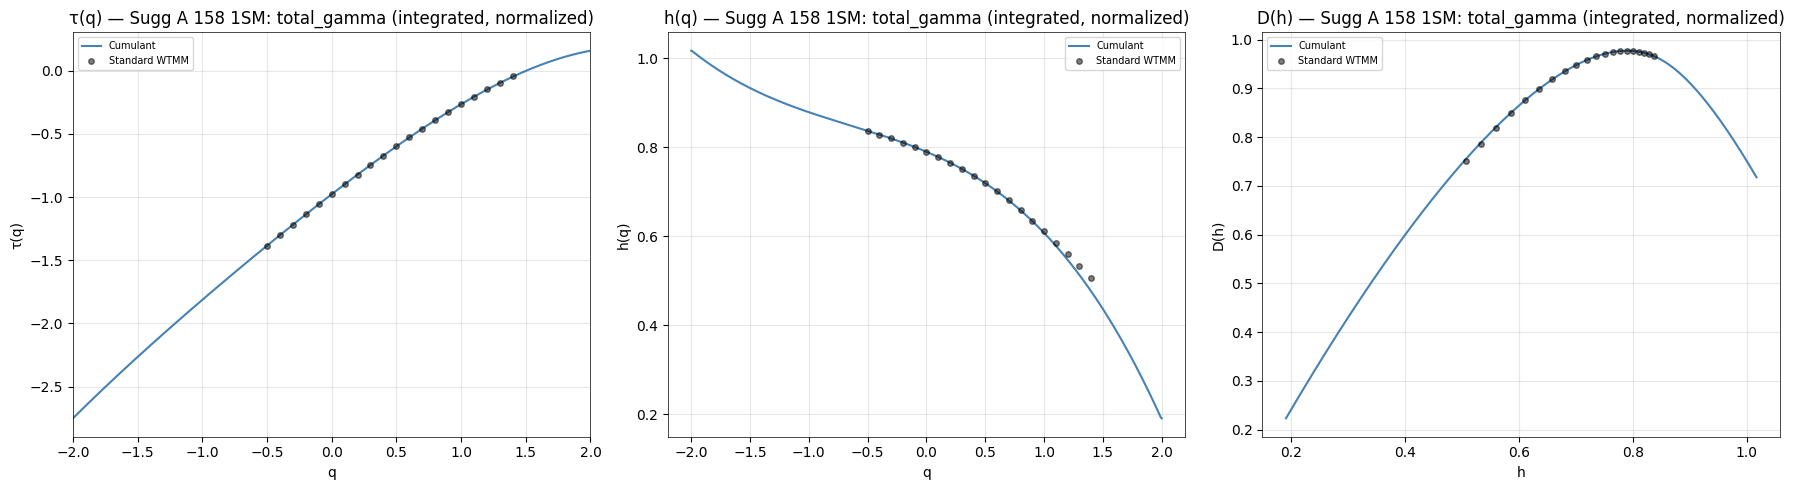


c₃ = -0.0933 → departure from log-normality


In [ ]:
# Cumulant analysis — non-truncated only
# τ(q) = -c₀ + c₁q - c₂q²/2! + c₃q³/3! + ...
# cₙ = slope of Cₙ(a) vs ln(a)

Q_RANGE_CUMULANT = (-2, 2)  # valid q range for reconstruction

n_scales = len(extrep_ord)
n_voice_cum = pf['n_voice']
ln_a = np.log(scales[:n_scales])

# --- Compute cumulants C_n(a) at each scale ---
cumulant_names = ['C₀ = ln(N_a)', 'C₁ = ⟨ln|T|⟩', 'C₂ = Var(ln|T|)',
                  'C₃ = μ₃(ln|T|)', 'C₄ (4th cum)']
names_short = ['c₀ (D_f)', 'c₁ (⟨h⟩)', 'c₂ (intermit.)', 'c₃ (skew)', 'c₄ (kurt)']
n_cumulants = len(cumulant_names)
sign_conv = [-1, 1, -1, 1, -1]

C = np.full((n_cumulants, n_scales), np.nan)
N_a = np.zeros(n_scales)

for s in range(n_scales):
    ords = extrep_ord[s]
    N_a[s] = len(ords)
    if len(ords) < 3:
        continue
    ln_T = np.log(np.abs(ords) + 1e-300)
    m1 = np.mean(ln_T)
    d = ln_T - m1
    C[0, s] = np.log(len(ords))
    C[1, s] = m1
    C[2, s] = np.mean(d**2)
    C[3, s] = np.mean(d**3)
    C[4, s] = np.mean(d**4) - 3 * np.mean(d**2)**2

# --- Fit slopes over regression range ---
log2_a0 = np.log2(scales[0])
dx_scale = 1.0 / n_voice_cum
idx_lo = max(int(round((LOG2_A_MIN - log2_a0) / dx_scale)), 0)
idx_hi = min(int(round((LOG2_A_MAX - log2_a0) / dx_scale)), n_scales - 1)
fit_idx = np.arange(idx_lo, idx_hi + 1)
x_fit = ln_a[fit_idx]

c_coeffs = np.zeros(n_cumulants)
c_err = np.zeros(n_cumulants)
c_r2 = np.zeros(n_cumulants)

fig, axes = plt.subplots(1, n_cumulants + 1, figsize=(4 * (n_cumulants + 1), 4))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

for n in range(n_cumulants):
    ax = axes[n]
    valid = np.isfinite(C[n])
    ax.plot(ln_a[valid], C[n, valid], 'o', color='steelblue', markersize=3, alpha=0.6)
    ax.axvspan(ln_a[idx_lo], ln_a[idx_hi], color='gray', alpha=0.06)

    y_fit = C[n, fit_idx]
    fmask = np.isfinite(y_fit)
    if fmask.sum() >= 3:
        slope, intercept = np.polyfit(x_fit[fmask], y_fit[fmask], 1)
        c_coeffs[n] = sign_conv[n] * slope
        y_pred = slope * x_fit[fmask] + intercept
        ss_res = np.sum((y_fit[fmask] - y_pred)**2)
        ss_tot = np.sum((y_fit[fmask] - y_fit[fmask].mean())**2)
        c_r2[n] = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
        n_pts = fmask.sum()
        c_err[n] = np.sqrt(ss_res / max(n_pts - 2, 1) /
                           np.sum((x_fit[fmask] - x_fit[fmask].mean())**2)) if n_pts > 2 else 0
        x_line = np.array([ln_a[valid].min(), ln_a[valid].max()])
        ax.plot(x_line, slope * x_line + intercept, '-', color='steelblue', lw=1.2)

    ax.set_title(f'{cumulant_names[n]}\n{names_short[n]}={c_coeffs[n]:+.4f}  R²={c_r2[n]:.4f}', fontsize=8)
    ax.set_xlabel('ln(a)', fontsize=8)
    ax.grid(True, alpha=0.3)

# N(a) panel
ax = axes[n_cumulants]
ax.plot(ln_a, N_a, 'o-', color='steelblue', markersize=3, lw=0.8)
ax.axvspan(ln_a[idx_lo], ln_a[idx_hi], color='gray', alpha=0.06)
ax.set_title('N(a)', fontsize=9)
ax.set_xlabel('ln(a)', fontsize=8)
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

plt.suptitle(f'{analysis_label} — Cumulants (log₂a ∈ [{LOG2_A_MIN}, {LOG2_A_MAX}])', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# --- Print coefficients ---
print(f'=== Cumulant coefficients ===')
for n in range(n_cumulants):
    print(f'  {names_short[n]:>22s} = {c_coeffs[n]:+.4f} ± {c_err[n]:.4f}   R² = {c_r2[n]:.6f}')

# --- Reconstruct τ(q), h(q), D(h) ---
q_recon = np.linspace(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1], 500)

tau_cum = -c_coeffs[0] + c_coeffs[1]*q_recon - c_coeffs[2]*q_recon**2/2 + c_coeffs[3]*q_recon**3/6 - c_coeffs[4]*q_recon**4/24
h_cum = np.gradient(tau_cum, q_recon)
D_cum = q_recon * h_cum - tau_cum

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# τ(q)
ax = axes[0]
ax.plot(q_recon, tau_cum, '-', color='steelblue', lw=1.5, label='Cumulant')
if has_theory:
    ax.plot(theory_q, theory_tau, 'k-', lw=1, label='Theory')
ax.plot(spectra['q_list'], spectra['tau_q'], 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
ax.set_xlabel('q'); ax.set_ylabel('τ(q)')
ax.set_title(f'τ(q) — {analysis_label}')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.set_xlim(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1])

# h(q)
ax = axes[1]
ax.plot(q_recon, h_cum, '-', color='steelblue', lw=1.5, label='Cumulant')
if has_theory and theory_h is not None and len(theory_h) > 1:
    ax.plot(theory_q, theory_h, 'k-', lw=1, label='Theory')
elif has_theory and theory_h is not None and len(theory_h) == 1:
    ax.axhline(theory_h[0], color='k', ls='--', lw=1, label=f'Theory h*={theory_h[0]:.3f}')
ax.plot(spectra['q_list'], spectra['h_q'], 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
ax.set_xlabel('q'); ax.set_ylabel('h(q)')
ax.set_title(f'h(q) — {analysis_label}')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# D(h)
ax = axes[2]
m = D_cum > -0.5
ax.plot(h_cum[m], D_cum[m], '-', color='steelblue', lw=1.5, label='Cumulant')
if has_theory and theory_h is not None and len(theory_h) > 1:
    tm = theory_D > -0.5
    ax.plot(theory_h[tm], theory_D[tm], 'k-', lw=1, label='Theory')
elif has_theory and theory_h is not None and len(theory_h) == 1:
    ax.plot(theory_h[0], theory_D[0], 'k*', markersize=15, label=f'Theory (h*={theory_h[0]:.3f})')
ax.plot(spectra['h_q'], spectra['D_q'], 'ko', markersize=4, alpha=0.5, linestyle='none', label='Standard WTMM')
ax.set_xlabel('h'); ax.set_ylabel('D(h)')
ax.set_title(f'D(h) — {analysis_label}')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Log-normality check: if c₃ ≈ 0, the cascade is approximately log-normal
if abs(c_coeffs[3]) < 0.01:
    print(f'\nc₃ = {c_coeffs[3]:+.4f} ≈ 0 → approximately log-normal cascade')
else:
    print(f'\nc₃ = {c_coeffs[3]:+.4f} → departure from log-normality')


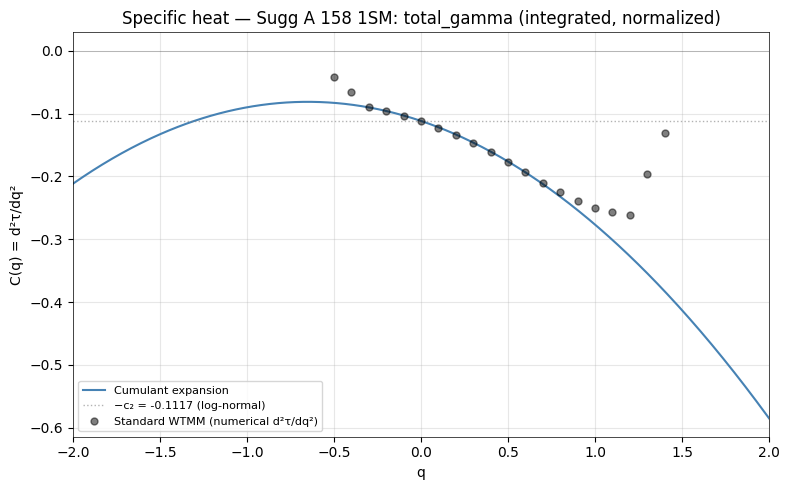

c₂ = 0.1117  →  −c₂ = -0.1117
c₃ = -0.0933  (slope of C(q) at q=0; =0 for log-normal)


In [161]:
# Specific heat C(q) = d²τ/dq²
# From cumulant expansion: C(q) = -c₂ + c₃q - c₄q²/2 + ...
# Monofractal: C(q) = 0 | Log-normal: C(q) = -c₂ (constant) | Phase transition: discontinuity

q_recon_ch = np.linspace(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1], 500)

# Analytical from cumulant coefficients
C_heat_cum = -c_coeffs[2] + c_coeffs[3] * q_recon_ch - c_coeffs[4] * q_recon_ch**2 / 2

# Numerical from standard WTMM τ(q)
q_wtmm = spectra['q_list']
tau_wtmm = spectra['tau_q']
finite = np.isfinite(tau_wtmm)
if finite.sum() >= 3:
    C_heat_wtmm = np.gradient(np.gradient(tau_wtmm[finite], q_wtmm[finite]), q_wtmm[finite])
else:
    C_heat_wtmm = None

fig, ax = plt.subplots(figsize=(8, 5))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

ax.plot(q_recon_ch, C_heat_cum, '-', color='steelblue', lw=1.5, label='Cumulant expansion')
ax.axhline(-c_coeffs[2], color='gray', ls=':', lw=1, alpha=0.6, label=f'−c₂ = {-c_coeffs[2]:.4f} (log-normal)')
ax.axhline(0, color='k', ls='-', lw=0.5, alpha=0.3)

if C_heat_wtmm is not None:
    ax.plot(q_wtmm[finite], C_heat_wtmm, 'ko', markersize=5, alpha=0.5, label='Standard WTMM (numerical d²τ/dq²)')

if has_theory:
    tau_th_fine = np.interp(q_recon_ch, theory_q, theory_tau)
    C_heat_theory = np.gradient(np.gradient(tau_th_fine, q_recon_ch), q_recon_ch)
    ax.plot(q_recon_ch, C_heat_theory, 'k-', lw=1, label='Theory')

ax.set_xlabel('q')
ax.set_ylabel('C(q) = d²τ/dq²')
ax.set_title(f'Specific heat — {analysis_label}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1])
plt.tight_layout()
plt.show()

print(f'c₂ = {c_coeffs[2]:.4f}  →  −c₂ = {-c_coeffs[2]:.4f}')
print(f'c₃ = {c_coeffs[3]:.4f}  (slope of C(q) at q=0; =0 for log-normal)')


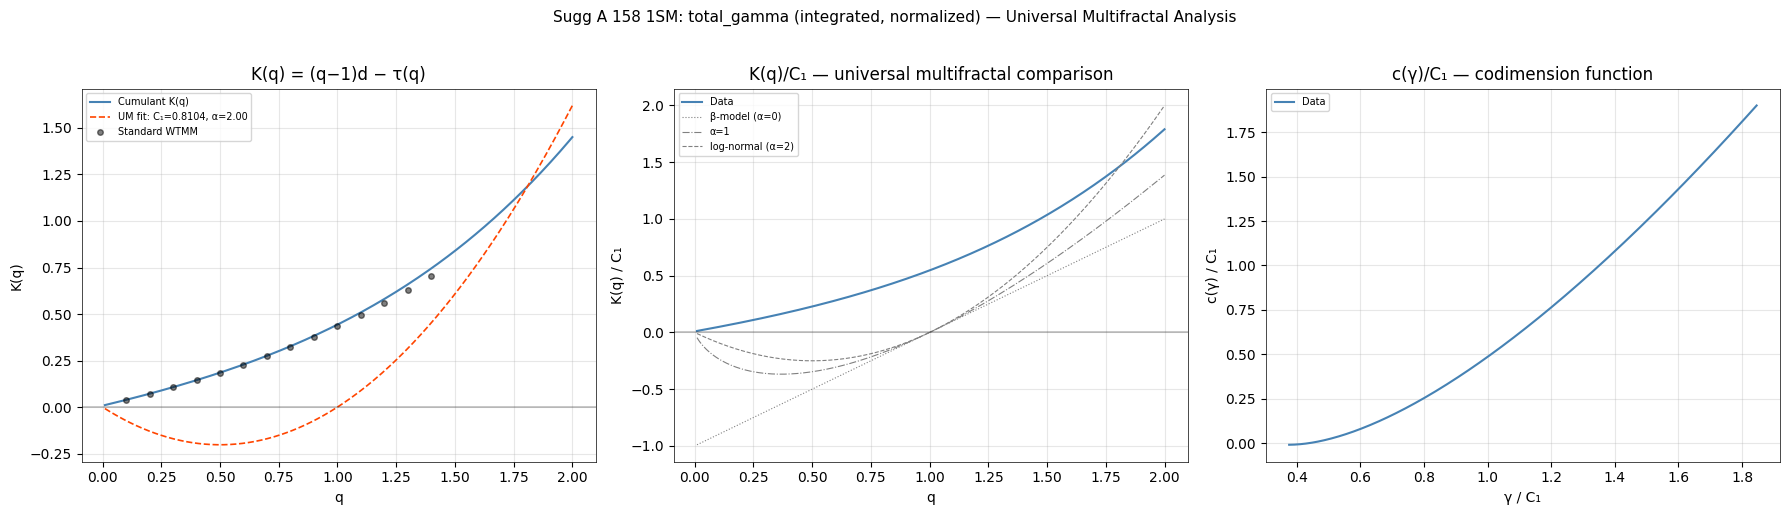

=== Universal Multifractal Parameters ===
  C₁ = 0.8104 ± 0.0631  (intermittency, cf. c₂ = 0.1666)
  α  = 2.000 ± 0.240  (Lévy index, 0=β-model, 2=log-normal)
  → Near log-normal (α ≈ 2)


In [135]:
# Universal Multifractal parameters (C₁, α) from WTMM
# K(q) = (q-1)·d - τ(q),  fit K(q) = C₁/(α-1)·(q^α - q) for α∈(0,2]
# c(γ) = Legendre transform of K(q) = codimension function = d - D(h)

from scipy.optimize import curve_fit

d = 1  # embedding dimension

# --- Compute K(q) from cumulant τ(q) ---
q_K = np.linspace(0.01, Q_RANGE_CUMULANT[1], 300)  # q > 0 for K(q)
tau_cum_K = -c_coeffs[0] + c_coeffs[1]*q_K - c_coeffs[2]*q_K**2/2 + c_coeffs[3]*q_K**3/6 - c_coeffs[4]*q_K**4/24
K_q = (q_K - 1) * d - tau_cum_K

# Also from standard WTMM
q_wtmm = np.array(spectra['q_list'], dtype=float)
tau_wtmm = np.array(spectra['tau_q'], dtype=float)
fmask = np.isfinite(tau_wtmm) & (q_wtmm > 0)
K_wtmm = (q_wtmm[fmask] - 1) * d - tau_wtmm[fmask]

# Theory K(q)
if has_theory:
    q_th_pos = theory_q[theory_q > 0]
    tau_th_pos = np.interp(q_th_pos, theory_q, theory_tau)
    K_theory = (q_th_pos - 1) * d - tau_th_pos

# --- Fit universal multifractal model ---
def K_universal(q, C1, alpha):
    """K(q) = C1/(alpha-1) * (q^alpha - q) for alpha != 1"""
    if abs(alpha - 1.0) < 1e-6:
        return C1 * q * np.log(q)
    return C1 / (alpha - 1) * (q**alpha - q)

# Fit on cumulant K(q) for q > 0.1
fit_mask = q_K > -1.1
try:
    popt, pcov = curve_fit(K_universal, q_K[fit_mask], K_q[fit_mask],
                           p0=[0.1, 1.5], bounds=([1e-6, 0.01], [5.0, 2.0]))
    C1_fit, alpha_fit = popt
    C1_err, alpha_err = np.sqrt(np.diag(pcov))
    K_fit = K_universal(q_K, C1_fit, alpha_fit)
    fit_ok = True
except Exception as e:
    print(f'Fit failed: {e}')
    fit_ok = False

# --- Legendre transform of K(q) → c(γ) ---
# γ = dK/dq,  c(γ) = q·γ - K(q)
dKdq = np.gradient(K_q, q_K)
gamma = dKdq
c_gamma = q_K * gamma - K_q

# Theory c(γ)
if has_theory:
    dK_th = np.gradient(K_theory, q_th_pos)
    gamma_th = dK_th
    c_gamma_th = q_th_pos * gamma_th - K_theory

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Panel 1: K(q) vs q
ax = axes[0]
ax.plot(q_K, K_q, '-', color='steelblue', lw=1.5, label='Cumulant K(q)')
if fit_ok:
    ax.plot(q_K, K_fit, '--', color='orangered', lw=1.2,
            label=f'UM fit: C₁={C1_fit:.4f}, α={alpha_fit:.2f}')
ax.plot(q_wtmm[fmask], K_wtmm, 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
if has_theory:
    ax.plot(q_th_pos, K_theory, 'k-', lw=1, label='Theory')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q'); ax.set_ylabel('K(q)')
ax.set_title('K(q) = (q−1)d − τ(q)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Panel 2: K(q)/C₁ vs q (normalized, like Lovejoy Fig 13)
ax = axes[1]
if fit_ok and C1_fit > 1e-8:
    ax.plot(q_K, K_q / C1_fit, '-', color='steelblue', lw=1.5, label='Data')
    # Reference curves for α = 0, 1, 2
    for a_ref, ls, lbl in [(0.0, ':', 'β-model (α=0)'),
                            (1.0, '-.', 'α=1'),
                            (2.0, '--', 'log-normal (α=2)')]:
        K_ref = K_universal(q_K, C1_fit, a_ref) / C1_fit
        ax.plot(q_K, K_ref, ls, color='gray', lw=0.8, label=lbl)
    ax.set_ylabel('K(q) / C₁')
else:
    ax.plot(q_K, K_q, '-', color='steelblue', lw=1.5)
    ax.set_ylabel('K(q)')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q')
ax.set_title('K(q)/C₁ — universal multifractal comparison')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Panel 3: c(γ)/C₁ vs γ/C₁ (codimension, like Lovejoy Fig 14)
ax = axes[2]
if fit_ok and C1_fit > 1e-8:
    ax.plot(gamma / C1_fit, c_gamma / C1_fit, '-', color='steelblue', lw=1.5, label='Data')
    if has_theory:
        ax.plot(gamma_th / C1_fit, c_gamma_th / C1_fit, 'k-', lw=1, label='Theory')
    ax.set_xlabel('γ / C₁'); ax.set_ylabel('c(γ) / C₁')
else:
    ax.plot(gamma, c_gamma, '-', color='steelblue', lw=1.5, label='Data')
    if has_theory:
        ax.plot(gamma_th, c_gamma_th, 'k-', lw=1, label='Theory')
    ax.set_xlabel('γ'); ax.set_ylabel('c(γ)')
ax.set_title('c(γ)/C₁ — codimension function')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle(f'{analysis_label} — Universal Multifractal Analysis', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# --- Summary ---
if fit_ok:
    print(f'=== Universal Multifractal Parameters ===')
    print(f'  C₁ = {C1_fit:.4f} ± {C1_err:.4f}  (intermittency, cf. c₂ = {c_coeffs[2]:.4f})')
    print(f'  α  = {alpha_fit:.3f} ± {alpha_err:.3f}  (Lévy index, 0=β-model, 2=log-normal)')
    if alpha_fit > 1.8:
        print(f'  → Near log-normal (α ≈ 2)')
    elif alpha_fit < 0.2:
        print(f'  → Near β-model (α ≈ 0)')
    else:
        print(f'  → Lévy multifractal with α = {alpha_fit:.2f}')
